# 06 Customer Churn Prediction and Retention Optimisation

## Project Background
In e-commerce, customer churn refers to users who stop purchasing within a given time window. Identifying potential churn early is important because retention is often more cost-effective than reacquisition, and small improvements in retention can create meaningful gains in customer lifetime value.

## Project Objective
This project builds a churn prediction workflow using customer behaviour, service experience, category preference, geographic context, and time-related features. The aim is not only to predict churn risk, but also to support **risk segmentation**, **high-priority user identification**, and **retention strategy design**.

## Analytical Scope
The project includes:
- churn label construction under multiple inactivity windows
- snapshot-based feature engineering
- grouped train/test split for leakage control
- imbalance-aware model comparison
- feature importance and SHAP interpretation
- churn risk segmentation and retention planning

## Key Business Question
How can the platform identify users at high risk of churn, understand the main drivers behind that risk, and allocate retention effort more effectively?

## Project Reflection
This project treats churn prediction as both a modelling task and a business decision problem. A useful churn model should not only achieve strong metrics, but also provide interpretable signals that can support **practical intervention** and **more efficient customer retention**.

## 1. Data Loading & Initial Exploration



In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import os

from pathlib import Path
from datetime import datetime, timedelta
from IPython.display import display

warnings.filterwarnings('ignore')

# Machine learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Evaluation metrics
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

# Model interpretation
import shap

# Display settings
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

### Reusable Utility Functions

All reusable validation and helper functions are defined **once** here and reused throughout the notebook. This avoids repeated function definitions later in the workflow.

In [2]:
# Reusable utility functions

def _normalize_key_cols(key=None, key_cols=None):
    cols = key_cols if key_cols is not None else key
    if cols is None:
        cols = 'unique_user_id'
    if isinstance(cols, str):
        cols = [cols]
    return list(cols)


def check_duplicate_keys(df, name, key=None, key_cols=None):
    key_cols = _normalize_key_cols(key=key, key_cols=key_cols)

    missing_cols = [col for col in key_cols if col not in df.columns]
    if missing_cols:
        print(f"{name:<28} missing key column(s): {missing_cols}")
        return

    dup_count = df.duplicated(subset=key_cols).sum()
    unique_count = df[key_cols].drop_duplicates().shape[0]

    print(
        f"{name:<28} rows={len(df):>6} | "
        f"unique_keys={unique_count:>6} | "
        f"duplicates={dup_count:>6} | "
        f"key_cols={key_cols}"
    )


def missing_summary(df, name):
    summary = (
        df.isnull().sum()
        .rename('missing_count')
        .to_frame()
        .assign(missing_rate=lambda x: x['missing_count'] / len(df))
        .query('missing_count > 0')
        .sort_values(['missing_count', 'missing_rate'], ascending=False)
    )

    print(f"{name} - missing value summary")
    if summary.empty:
        print("No missing values.\n")
    else:
        display(summary)
        print()

    return summary


def mode_or_null(series):
    mode_vals = series.dropna().mode()
    return mode_vals.iloc[0] if not mode_vals.empty else np.nan


def save_sql(sql_text, file_path):
    file_path.parent.mkdir(parents=True, exist_ok=True)
    file_path.write_text(sql_text.strip(), encoding='utf-8')
    print(f"SQL saved to: {file_path}")


def sanitize_col_name(value):
    value = str(value).strip().lower()
    value = re.sub(r'[^0-9a-zA-Z]+', '_', value)
    value = re.sub(r'_+', '_', value).strip('_')
    return value if value else 'unknown'


def standardize_to_unique_user_id(df, name, user_key_map=None):
    df = df.copy()

    if 'unique_user_id' in df.columns:
        return df

    if 'user_id' in df.columns:
        if user_key_map is None:
            raise ValueError(f"{name} needs user_key_map to convert user_id -> unique_user_id")

        df = df.merge(user_key_map, on='user_id', how='left')

        missing_key = df['unique_user_id'].isnull().sum()
        if missing_key > 0:
            print(f"Warning: {name} has {missing_key} rows without unique_user_id after mapping")

        df = df.drop(columns=['user_id'])
        return df

    raise KeyError(f"{name} does not contain 'user_id' or 'unique_user_id'")


def assert_unique_key(df, name, key=None, key_cols=None):
    key_cols = _normalize_key_cols(key=key, key_cols=key_cols)

    missing_cols = [col for col in key_cols if col not in df.columns]
    assert not missing_cols, f"{name} missing key column(s): {missing_cols}"

    dup_count = df.duplicated(subset=key_cols).sum()
    assert dup_count == 0, f"{name} still contains {dup_count} duplicated rows on key {key_cols}"


def safe_read_csv(path, **kwargs):
    path = Path(path)
    if path.exists():
        return pd.read_csv(path, **kwargs)
    print(f"Warning: file not found -> {path}")
    return pd.DataFrame()


def safe_select(df, cols):
    return df[[col for col in cols if col in df.columns]].copy()


def get_existing_targets(df):
    candidate_targets = ['is_churned_30d', 'is_churned_60d', 'is_churned_90d', 'target']
    return [col for col in candidate_targets if col in df.columns]

### 1.1 Churn Label Data Loading

The first step of this project is to load the **snapshot-based churn label table** from the MySQL data warehouse.
Rather than defining churn from a single static customer table, this project constructs repeated monthly observation snapshots, where each row represents a customer observed at a specific time point. For each snapshot, multiple churn labels are generated, including ``is_churned_30d``, ``is_churned_60d``, ``is_churned_90d``, ``is_churned_180d``, and ``is_churned_270d``.

This design is more appropriate for churn modelling because it preserves the **time-dependent nature of customer inactivity**. It also allows the project to compare alternative churn windows instead of assuming that one universal threshold is always correct. In addition, the label table retains key lifecycle information linked to each snapshot, which provides the foundation for later feature alignment and supervised learning.

In [3]:
# connect to MySQL data warehouse

from src.utils.db import get_engine
from sqlalchemy import text

engine = get_engine()

In [4]:
# Locate project root automatically

candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent
]

project_root = None

for root in candidate_roots:
    if (root / 'src' / 'utils' / 'db.py').exists():
        project_root = root
        break

if project_root is None:
    raise FileNotFoundError("Cannot locate project root containing output/user_segments_rfm.csv")

print("Project root found at:")
print(project_root)

Project root found at:
C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence


In [5]:
# Define external file paths

sql_dir = project_root / 'sql' / '06_customer_churn_prediction'
output_dir = project_root / 'output' / '06_churn_prediction'
output_dir.mkdir(parents=True, exist_ok=True)

print("User segments path:")

print("\nState clusters path:")

print("\nSQL directory:")
print(sql_dir)

print("\nOutput directory:")
print(output_dir)

User segments path:

State clusters path:

SQL directory:
C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\sql\06_customer_churn_prediction

Output directory:
C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\06_churn_prediction


In [6]:
def create_index_if_missing(table_name, index_name, ddl):
    check_sql = f"""
    SELECT COUNT(*) AS cnt
    FROM information_schema.STATISTICS
    WHERE TABLE_SCHEMA = DATABASE()
      AND TABLE_NAME = '{table_name}'
      AND INDEX_NAME = '{index_name}'
    """
    cnt = pd.read_sql(check_sql, engine).loc[0, 'cnt']

    if cnt == 0:
        with engine.begin() as conn:
            conn.execute(text(ddl))
        print(f"Created index: {index_name}")
    else:
        print(f"Index already exists: {index_name}")

create_index_if_missing(
    'dim_user',
    'idx_unique_user_id',
    'CREATE INDEX idx_unique_user_id ON dim_user(unique_user_id)'
)

create_index_if_missing(
    'fact_order',
    'idx_order_status_purchase',
    'CREATE INDEX idx_order_status_purchase ON fact_order(order_status, purchase_ts)'
)

Index already exists: idx_unique_user_id
Index already exists: idx_order_status_purchase


In [7]:
# Create churn label table SQL using rolling snapshots
# Use longer future windows for a low-frequency ecommerce business

snapshot_offsets = [450, 420, 390, 360, 330, 300, 270]
min_total_orders = 2
min_customer_age_days = 30
active_window_days = 60

snapshot_cte = "\n    UNION ALL\n".join(
    [
        f"SELECT {i+1} AS snapshot_id, DATE_SUB(data_end_date, INTERVAL {offset} DAY) AS obs_date FROM params"
        for i, offset in enumerate(snapshot_offsets)
    ]
)

create_table_sql = f"""
CREATE TABLE churn_labels_tmp AS
WITH params AS (
    SELECT
        MAX(purchase_ts) AS data_end_date
    FROM fact_order
    WHERE order_status = 'delivered'
),
snapshot_dates AS (
    {snapshot_cte}
),
order_gmv AS (
    SELECT
        order_id,
        SUM(gmv) AS order_gmv
    FROM fact_order_item
    GROUP BY order_id
),
history_orders AS (
    SELECT
        CONCAT(du.unique_user_id, '__', DATE_FORMAT(sd.obs_date, '%Y%m%d')) AS snapshot_key,
        sd.snapshot_id,
        sd.obs_date,
        du.unique_user_id,
        fo.order_id,
        fo.purchase_ts,
        COALESCE(og.order_gmv, 0) AS order_gmv
    FROM snapshot_dates sd
    JOIN fact_order fo
        ON fo.order_status = 'delivered'
       AND fo.purchase_ts <= sd.obs_date
    JOIN dim_user du
        ON fo.user_id = du.user_id
    LEFT JOIN order_gmv og
        ON fo.order_id = og.order_id
    WHERE du.unique_user_id IS NOT NULL
),
user_history AS (
    SELECT
        snapshot_key,
        snapshot_id,
        obs_date,
        unique_user_id,
        MIN(purchase_ts) AS first_purchase_date,
        MAX(purchase_ts) AS last_purchase_date,
        COUNT(DISTINCT order_id) AS total_orders,
        SUM(order_gmv) AS total_gmv,
        DATEDIFF(obs_date, MAX(purchase_ts)) AS days_since_last_order,
        DATEDIFF(obs_date, MIN(purchase_ts)) AS customer_age_days
    FROM history_orders
    GROUP BY snapshot_key, snapshot_id, obs_date, unique_user_id
),
eligible_users AS (
    SELECT *
    FROM user_history
    WHERE total_orders >= {min_total_orders}
      AND customer_age_days >= {min_customer_age_days}
      AND days_since_last_order <= {active_window_days}
),
future_activity AS (
    SELECT
        eu.snapshot_key,
        MAX(CASE WHEN fo.purchase_ts <= DATE_ADD(eu.obs_date, INTERVAL 30 DAY) THEN 1 ELSE 0 END) AS purchased_within_30d,
        MAX(CASE WHEN fo.purchase_ts <= DATE_ADD(eu.obs_date, INTERVAL 60 DAY) THEN 1 ELSE 0 END) AS purchased_within_60d,
        MAX(CASE WHEN fo.purchase_ts <= DATE_ADD(eu.obs_date, INTERVAL 90 DAY) THEN 1 ELSE 0 END) AS purchased_within_90d,
        MAX(CASE WHEN fo.purchase_ts <= DATE_ADD(eu.obs_date, INTERVAL 180 DAY) THEN 1 ELSE 0 END) AS purchased_within_180d,
        MAX(CASE WHEN fo.purchase_ts <= DATE_ADD(eu.obs_date, INTERVAL 270 DAY) THEN 1 ELSE 0 END) AS purchased_within_270d
    FROM eligible_users eu
    JOIN dim_user du
        ON eu.unique_user_id = du.unique_user_id
    JOIN fact_order fo
        ON du.user_id = fo.user_id
    WHERE fo.order_status = 'delivered'
      AND fo.purchase_ts > eu.obs_date
      AND fo.purchase_ts <= DATE_ADD(eu.obs_date, INTERVAL 270 DAY)
    GROUP BY eu.snapshot_key
)
SELECT
    eu.snapshot_key,
    eu.snapshot_id,
    eu.unique_user_id,
    eu.first_purchase_date,
    eu.last_purchase_date,
    eu.obs_date,
    CASE WHEN COALESCE(fa.purchased_within_30d, 0) = 1 THEN 0 ELSE 1 END AS is_churned_30d,
    CASE WHEN COALESCE(fa.purchased_within_60d, 0) = 1 THEN 0 ELSE 1 END AS is_churned_60d,
    CASE WHEN COALESCE(fa.purchased_within_90d, 0) = 1 THEN 0 ELSE 1 END AS is_churned_90d,
    CASE WHEN COALESCE(fa.purchased_within_180d, 0) = 1 THEN 0 ELSE 1 END AS is_churned_180d,
    CASE WHEN COALESCE(fa.purchased_within_270d, 0) = 1 THEN 0 ELSE 1 END AS is_churned_270d,
    eu.total_orders,
    eu.total_gmv,
    eu.days_since_last_order,
    eu.customer_age_days
FROM eligible_users eu
LEFT JOIN future_activity fa
    ON eu.snapshot_key = fa.snapshot_key
"""

save_sql(create_table_sql, sql_dir / 'create_view_user_churn_labels.sql')
print("The full SQL has been saved to a .sql file to avoid notebook output truncation.")

SQL saved to: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\sql\06_customer_churn_prediction\create_view_user_churn_labels.sql
The full SQL has been saved to a .sql file to avoid notebook output truncation.


In [8]:
# Execute SQL and create churn label table + indexes

with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS churn_labels_tmp"))
    conn.execute(text(create_table_sql))
    conn.execute(text("CREATE INDEX idx_churn_snapshot_key ON churn_labels_tmp(snapshot_key)"))
    conn.execute(text("CREATE INDEX idx_churn_user_obs ON churn_labels_tmp(unique_user_id, obs_date)"))
    conn.execute(text("CREATE INDEX idx_churn_snapshot_id ON churn_labels_tmp(snapshot_id)"))
    conn.execute(text("CREATE OR REPLACE VIEW view_user_churn_labels AS SELECT * FROM churn_labels_tmp"))

table_check_sql = """
SELECT COUNT(*) AS table_exists
FROM information_schema.TABLES
WHERE TABLE_SCHEMA = DATABASE()
  AND TABLE_NAME = 'churn_labels_tmp'
"""

table_check = pd.read_sql(table_check_sql, engine)
assert table_check.loc[0, 'table_exists'] == 1, "churn_labels_tmp was not created successfully"

print("churn_labels_tmp created successfully with rolling snapshots.")

churn_labels_tmp created successfully with rolling snapshots.


In [9]:
# Load churn label data

sql_churn = """
SELECT *
FROM churn_labels_tmp
ORDER BY snapshot_id, unique_user_id
"""

df_churn = pd.read_sql(sql_churn, engine)

print(f"Churn label data shape: {df_churn.shape}")
df_churn.head()

Churn label data shape: (1224, 15)


,snapshot_key,snapshot_id,unique_user_id,first_purchase_date,last_purchase_date,obs_date,is_churned_30d,is_churned_60d,is_churned_90d,is_churned_180d,is_churned_270d,total_orders,total_gmv,days_since_last_order,customer_age_days
0,015557c9912277312b9073947804a7ba__20170605,1,015557c9912277312b9073947804a7ba,2017-03-23 22:45:46,2017-05-01 14:48:33,2017-06-05 15:00:37,1,1,1,1,1,2,315.12,35,74
1,0396c443fdda5498c7e9ed5b34871c5a__20170605,1,0396c443fdda5498c7e9ed5b34871c5a,2017-05-05 08:44:57,2017-05-05 08:44:58,2017-06-05 15:00:37,1,1,1,1,1,2,120.84,31,31
2,03dabd77cb0ed7a26fafe19e36b67742__20170605,1,03dabd77cb0ed7a26fafe19e36b67742,2017-04-11 18:19:55,2017-05-15 10:14:17,2017-06-05 15:00:37,1,1,1,1,1,2,99.45,21,55
3,06a52782a04f0086d16b9c22d0e29438__20170605,1,06a52782a04f0086d16b9c22d0e29438,2017-05-06 20:11:10,2017-05-06 20:11:11,2017-06-05 15:00:37,1,1,1,1,1,3,153.33,30,30
4,0981a271500799427cdf345e9121e20b__20170605,1,0981a271500799427cdf345e9121e20b,2017-04-03 13:57:14,2017-04-17 10:05:11,2017-06-05 15:00:37,1,1,1,1,1,2,162.28,49,63


In [10]:
# Validate rolling snapshot coverage and target distribution

date_cols = ['first_purchase_date', 'last_purchase_date', 'obs_date']
for col in date_cols:
    df_churn[col] = pd.to_datetime(df_churn[col])

snapshot_calendar = (
    df_churn[['snapshot_id', 'obs_date']]
    .drop_duplicates()
    .sort_values('obs_date')
    .reset_index(drop=True)
)

print("Snapshot calendar:")
display(snapshot_calendar)

snapshot_summary = (
    df_churn
    .groupby(['snapshot_id', 'obs_date'], as_index=False)
    .agg(
        rows=('snapshot_key', 'size'),
        unique_users=('unique_user_id', 'nunique'),
        churn_30d=('is_churned_30d', 'mean'),
        churn_60d=('is_churned_60d', 'mean'),
        churn_90d=('is_churned_90d', 'mean'),
        churn_180d=('is_churned_180d', 'mean'),
        churn_270d=('is_churned_270d', 'mean')
    )
)

print("Snapshot-level churn summary:")
display(snapshot_summary)

overall_rates = (
    df_churn[
        ['is_churned_30d', 'is_churned_60d', 'is_churned_90d', 'is_churned_180d', 'is_churned_270d']
    ]
    .mean()
    .mul(100)
    .round(2)
    .to_frame('rate_pct')
)

print("Overall churn rates (%):")
display(overall_rates)

Snapshot calendar:


,snapshot_id,obs_date
0,1,2017-06-05 15:00:37
1,2,2017-07-05 15:00:37
2,3,2017-08-04 15:00:37
3,4,2017-09-03 15:00:37
4,5,2017-10-03 15:00:37
5,6,2017-11-02 15:00:37
6,7,2017-12-02 15:00:37


Snapshot-level churn summary:


,snapshot_id,obs_date,rows,unique_users,churn_30d,churn_60d,churn_90d,churn_180d,churn_270d
0,1,2017-06-05 15:00:37,83,83,0.963855,0.963855,0.939759,0.927711,0.903614
1,2,2017-07-05 15:00:37,136,136,0.985294,0.963235,0.963235,0.933824,0.911765
2,3,2017-08-04 15:00:37,148,148,0.979730,0.959459,0.952703,0.932432,0.918919
3,4,2017-09-03 15:00:37,169,169,0.952663,0.934911,0.928994,0.917160,0.905325
4,5,2017-10-03 15:00:37,203,203,0.965517,0.945813,0.945813,0.896552,0.876847
5,6,2017-11-02 15:00:37,227,227,0.955947,0.951542,0.947137,0.903084,0.894273
6,7,2017-12-02 15:00:37,258,258,0.988372,0.968992,0.953488,0.906977,0.891473


Overall churn rates (%):


,rate_pct
is_churned_30d,97.06
is_churned_60d,95.51
is_churned_90d,94.77
is_churned_180d,91.34
is_churned_270d,89.79


In [11]:
# Load user key mapping table for later key standardization

sql_user_key_map = """
SELECT
    user_id,
    unique_user_id
FROM dim_user
"""

df_user_key_map = pd.read_sql(sql_user_key_map, engine)
print(f"User key mapping shape: {df_user_key_map.shape}")
df_user_key_map.head()

User key mapping shape: (99441, 2)


,user_id,unique_user_id
0,fadbb3709178fc513abc1b2670aa1ad2,0000366f3b9a7992bf8c76cfdf3221e2
1,4cb282e167ae9234755102258dd52ee8,0000b849f77a49e4a4ce2b2a4ca5be3f
2,9b3932a6253894a02c1df9d19004239f,0000f46a3911fa3c0805444483337064
3,914991f0c02ef0843c0e7010c819d642,0000f6ccb0745a6a4b88665a16c9f078
4,47227568b10f5f58a524a75507e6992c,0004aac84e0df4da2b147fca70cf8255


In [12]:
# Load satisfaction and logistics-related snapshot-safe features

sql_satisfaction = """
SELECT
    c.snapshot_key,
    c.snapshot_id,
    c.unique_user_id,
    c.obs_date,
    AVG(r.review_score) AS avg_rating,
    STDDEV(r.review_score) AS rating_std,
    SUM(CASE WHEN r.review_score <= 2 THEN 1 ELSE 0 END) AS bad_review_count,
    AVG(o.delivered_days) AS avg_delivery_days,
    SUM(
        CASE
            WHEN o.delivered_ts > o.estimated_delivery_ts THEN 1
            ELSE 0
        END
    ) AS delayed_orders
FROM churn_labels_tmp c
JOIN dim_user u
    ON c.unique_user_id = u.unique_user_id
JOIN fact_order o
    ON u.user_id = o.user_id
LEFT JOIN fact_review r
    ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.purchase_ts <= c.obs_date
  AND (o.delivered_ts IS NULL OR o.delivered_ts <= c.obs_date)
GROUP BY c.snapshot_key, c.snapshot_id, c.unique_user_id, c.obs_date
"""

df_satisfaction = pd.read_sql(sql_satisfaction, engine)

print(f"Satisfaction feature data shape: {df_satisfaction.shape}")
df_satisfaction.head()

Satisfaction feature data shape: (1224, 9)


,snapshot_key,snapshot_id,unique_user_id,obs_date,avg_rating,rating_std,bad_review_count,avg_delivery_days,delayed_orders
0,015557c9912277312b9073947804a7ba__20170605,1,015557c9912277312b9073947804a7ba,2017-06-05 15:00:37,5.0,0.0,0.0,13.0,0.0
1,02168ea18740a0fdaaa15f11bebba5db__20171102,6,02168ea18740a0fdaaa15f11bebba5db,2017-11-02 15:00:37,3.0,2.0,1.0,22.5,1.0
2,02168ea18740a0fdaaa15f11bebba5db__20171202,7,02168ea18740a0fdaaa15f11bebba5db,2017-12-02 15:00:37,3.0,2.0,1.0,22.5,1.0
3,027803eb28cc01fbdf5da72b109fabee__20171202,7,027803eb28cc01fbdf5da72b109fabee,2017-12-02 15:00:37,5.0,0.0,0.0,16.0,0.0
4,031ea691b99fc101dcad357d1a83573f__20170804,3,031ea691b99fc101dcad357d1a83573f,2017-08-04 15:00:37,4.0,0.0,0.0,7.5,0.0


In [13]:
# Load geographic feature data

sql_geo = """
SELECT
    unique_user_id,
    state AS customer_state,
    city AS customer_city
FROM dim_user
"""

df_geo = pd.read_sql(sql_geo, engine)

print(f"Geographic feature data shape: {df_geo.shape}")
df_geo.head()

Geographic feature data shape: (99441, 3)


,unique_user_id,customer_state,customer_city
0,248ffe10d632bebe4f7267f1f44844c9,SP,osasco
1,b0015e09bb4b6e47c52844fab5fb6638,MG,itapecerica
2,94b11d37cd61cb2994a194d11f89682b,ES,nova venecia
3,4893ad4ea28b2c5b3ddf4e82e79db9e6,MG,mendonca
4,0b83f73b19c2019e182fd552c048a22c,SP,sao paulo


In [14]:
# Load category preference feature data at snapshot-user-category level

sql_category = """
SELECT
    c.snapshot_key,
    c.snapshot_id,
    c.unique_user_id,
    c.obs_date,
    p.category,
    COUNT(*) AS category_purchases,
    SUM(oi.gmv) AS category_gmv
FROM churn_labels_tmp c
JOIN dim_user u
    ON c.unique_user_id = u.unique_user_id
JOIN fact_order o
    ON u.user_id = o.user_id
JOIN fact_order_item oi
    ON o.order_id = oi.order_id
LEFT JOIN dim_product p
    ON oi.product_id = p.product_id
WHERE o.order_status = 'delivered'
  AND o.purchase_ts <= c.obs_date
  AND p.category IS NOT NULL
GROUP BY c.snapshot_key, c.snapshot_id, c.unique_user_id, c.obs_date, p.category
"""

df_category = pd.read_sql(sql_category, engine)

print(f"Category preference data shape: {df_category.shape}")
df_category.head()

Category preference data shape: (1889, 7)


,snapshot_key,snapshot_id,unique_user_id,obs_date,category,category_purchases,category_gmv
0,015557c9912277312b9073947804a7ba__20170605,1,015557c9912277312b9073947804a7ba,2017-06-05 15:00:37,utilidades_domesticas,1,72.90
1,015557c9912277312b9073947804a7ba__20170605,1,015557c9912277312b9073947804a7ba,2017-06-05 15:00:37,cama_mesa_banho,1,242.22
2,02168ea18740a0fdaaa15f11bebba5db__20171102,6,02168ea18740a0fdaaa15f11bebba5db,2017-11-02 15:00:37,moveis_decoracao,4,264.04
3,02168ea18740a0fdaaa15f11bebba5db__20171202,7,02168ea18740a0fdaaa15f11bebba5db,2017-12-02 15:00:37,moveis_decoracao,4,264.04
4,027803eb28cc01fbdf5da72b109fabee__20171202,7,027803eb28cc01fbdf5da72b109fabee,2017-12-02 15:00:37,moveis_sala,1,44.83


### Summary and Reflection

The loading results show that the churn label table contains **1,224 snapshot-level customer observations** across **7 observation dates**, which means the modelling task is not based on a single cross-section, but on a small rolling panel of customers over time. This is an important strength because it makes the later prediction task more realistic than a one-off customer classification exercise.

At the same time, the label distribution reveals a critical issue: **all churn definitions are highly imbalanced toward the churned class**. Even the longest window, ``is_churned_270d``, still has a churn rate close to 90%, while ``is_churned_30d`` is above 97%. This suggests that, in this dataset, churn is effectively capturing **long purchase inactivity in a low-frequency e-commerce setting**, rather than a rare event. From a modelling perspective, this is both useful and problematic. It is useful because it reflects real customer behaviour in the business context; however, it is also problematic because such extreme class imbalance can reduce the practical value of standard accuracy-based evaluation and make some prediction tasks less discriminative.

Another important observation is that the different source tables have **very different granularities and row counts**. The churn label table and satisfaction table are already close to the modelling unit, while the geographic table is stored at the customer level and the category table is still at the **snapshot-user-category level**. This means the project cannot merge all tables directly without first resolving **key consistency, granularity mismatch, and aggregation logic**. In other words, successful modelling here depends not only on machine learning choice, but also on whether the data engineering decisions are conceptually sound.

Overall, this step confirms that the project has established a meaningful churn labelling framework, but it also raises a deeper methodological question: **which churn horizon is most useful for decision-making, not just easiest for modelling**? A shorter window may be more actionable, while a longer window may be more stable. Therefore, the choice of the final target should be justified by both business interpretation and statistical behaviour, rather than selected mechanically.

### 1.2 Data Quality Check

This step validates raw dataset structure, key consistency, granularity, duplicate records, and missing values before any merge takes place.

In [15]:
# Standardize retained datasets to the same customer key: unique_user_id

df_churn_std = standardize_to_unique_user_id(df_churn, 'df_churn', df_user_key_map)
df_satisfaction_std = standardize_to_unique_user_id(df_satisfaction, 'df_satisfaction', df_user_key_map)
df_geo_std = standardize_to_unique_user_id(df_geo, 'df_geo', df_user_key_map)
df_category_std = standardize_to_unique_user_id(df_category, 'df_category', df_user_key_map)

datasets = {
    'df_churn_std': df_churn_std,
    'df_satisfaction_std': df_satisfaction_std,
    'df_geo_std': df_geo_std,
    'df_category_std': df_category_std
}

overview = pd.DataFrame({
    'dataset': list(datasets.keys()),
    'rows': [len(df) for df in datasets.values()],
    'columns': [df.shape[1] for df in datasets.values()]
})

display(overview)

,dataset,rows,columns
0,df_churn_std,1224,15
1,df_satisfaction_std,1224,9
2,df_geo_std,99441,3
3,df_category_std,1889,7


In [16]:
# Check duplicates in retained tables

check_duplicate_keys(df_churn_std, 'df_churn_std', key_cols='snapshot_key')
check_duplicate_keys(df_satisfaction_std, 'df_satisfaction_std', key_cols='snapshot_key')
check_duplicate_keys(df_category_std, 'df_category_std', key_cols=['snapshot_key', 'category'])
check_duplicate_keys(df_geo_std, 'df_geo_std', key_cols='unique_user_id')

df_churn_std                 rows=  1224 | unique_keys=  1224 | duplicates=     0 | key_cols=['snapshot_key']
df_satisfaction_std          rows=  1224 | unique_keys=  1224 | duplicates=     0 | key_cols=['snapshot_key']
df_category_std              rows=  1889 | unique_keys=  1889 | duplicates=     0 | key_cols=['snapshot_key', 'category']
df_geo_std                   rows= 99441 | unique_keys= 96096 | duplicates=  3345 | key_cols=['unique_user_id']


In [17]:
# Check category data granularity because it is still snapshot-user-category level

print("df_category_std granularity check")
print("-" * 60)
print(f"Total rows                            : {len(df_category_std)}")
print(f"Unique snapshots                      : {df_category_std['snapshot_key'].nunique()}")
print(f"Unique users                          : {df_category_std['unique_user_id'].nunique()}")
print(f"Unique categories                     : {df_category_std['category'].nunique()}")
print(
    f"Duplicated snapshot-user-category rows: "
    f"{df_category_std.duplicated(subset=['snapshot_key', 'unique_user_id', 'category']).sum()}"
)

df_category_std granularity check
------------------------------------------------------------
Total rows                            : 1889
Unique snapshots                      : 1224
Unique users                          : 830
Unique categories                     : 51
Duplicated snapshot-user-category rows: 0


In [18]:
# Check missing values in all raw inputs

for name, df in datasets.items():
    missing_summary(df, name)

df_churn_std - missing value summary
No missing values.

df_satisfaction_std - missing value summary


,missing_count,missing_rate
avg_rating,7,0.005719
rating_std,7,0.005719



df_geo_std - missing value summary
No missing values.

df_category_std - missing value summary
No missing values.



### Data Quality Check Analysis

The quality check shows that the source tables are **not yet ready for direct merging**, mainly because they follow different keys and granularities. ``df_churn_std`` and ``df_satisfaction_std`` are both unique at the ``snapshot_key`` level, so they are structurally aligned with the churn-label table. In contrast, ``df_category_std`` is still stored at the **snapshot-user-category** level, which means it must be aggregated before it can be merged into a customer-snapshot modelling table. In addition, ``df_geo_std`` still contains duplicated ``unique_user_id`` values, so it is not yet a strict one-to-one customer lookup table.

Missing values are very limited. Only ``df_satisfaction_std`` shows small gaps in ``avg_rating`` and ``rating_std``, and these are more likely to reflect **customers without review behaviour** than random data corruption. This is an important reminder that missingness can itself carry behavioural meaning. Overall, the main issue at this stage is **not heavy data loss, but merge readiness**: the project must first resolve duplication, key consistency, and granularity alignment before the final modelling table can be considered reliable.

In [19]:
# Compare class balance across 30d, 60d, and 90d churn definitions

target_balance = pd.DataFrame({
    'target': ['is_churned_30d', 'is_churned_60d', 'is_churned_90d'],
    'positive_count': [
        df_churn_std['is_churned_30d'].sum(),
        df_churn_std['is_churned_60d'].sum(),
        df_churn_std['is_churned_90d'].sum()
    ],
    'total_count': [len(df_churn_std)] * 3
})

target_balance['churn_rate'] = target_balance['positive_count'] / target_balance['total_count']
target_balance['negative_count'] = target_balance['total_count'] - target_balance['positive_count']
target_balance['negative_to_positive_ratio'] = target_balance['negative_count'] / target_balance['positive_count']

display(target_balance)

,target,positive_count,total_count,churn_rate,negative_count,negative_to_positive_ratio
0,is_churned_30d,1188,1224,0.970588,36,0.030303
1,is_churned_60d,1169,1224,0.955065,55,0.047049
2,is_churned_90d,1160,1224,0.947712,64,0.055172


### Target Variable Decision

The comparison shows that all three candidate churn labels are **extremely imbalanced**, and in each case the churned class is the majority rather than the minority. This means the modelling task is not a conventional churn-detection problem, but a harder distinction between a small active group and a much larger inactive population. As a result, later evaluation cannot rely only on simple accuracy, because high performance may still hide weak discrimination.

Among the three short-horizon options, ``is_churned_60d`` appears to be the most reasonable **intermediate candidate**. ``30d`` is likely too sensitive and may treat temporary purchase gaps as churn, while ``90d`` is more stable but less timely for intervention. Therefore, ``60d`` can be viewed as a useful working benchmark at this stage. However, this choice should still be treated **critically rather than mechanically**, because the final target should depend not only on class balance, but also on how well the churn window matches business decision-making and customer purchase rhythm.

### 1.3 Data Cleaning & Merging

This section performs the final **snapshot-level data preparation** for modelling. It includes category-feature aggregation, retention of snapshot-safe variables, one-step merging based on ``df_churn_model``, missing-value handling, and structural validation checks. The goal is to ensure that all retained features are aligned to the same observation-time logic before model training.

In [20]:
# Build snapshot-level category preference features (aggregation + pivot)

df_category_std['category'] = df_category_std['category'].fillna('unknown')

group_cols = ['snapshot_key', 'snapshot_id', 'unique_user_id', 'obs_date']

category_summary = (
    df_category_std
    .groupby(group_cols, as_index=False)
    .agg(
        category_diversity=('category', 'nunique'),
        total_category_purchases=('category_purchases', 'sum'),
        total_category_gmv=('category_gmv', 'sum')
    )
)

top_categories = (
    df_category_std
    .groupby('category')['category_gmv']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

df_category_top = df_category_std[df_category_std['category'].isin(top_categories)].copy()
df_category_top['category_clean'] = df_category_top['category'].map(sanitize_col_name)

pivot_purchase = (
    df_category_top
    .pivot_table(
        index=group_cols,
        columns='category_clean',
        values='category_purchases',
        aggfunc='sum',
        fill_value=0
    )
    .add_prefix('cat_purchase_')
    .reset_index()
)

pivot_gmv = (
    df_category_top
    .pivot_table(
        index=group_cols,
        columns='category_clean',
        values='category_gmv',
        aggfunc='sum',
        fill_value=0
    )
    .add_prefix('cat_gmv_')
    .reset_index()
)

dominant_category = (
    df_category_std
    .sort_values(
        group_cols + ['category_gmv', 'category_purchases'],
        ascending=[True, True, True, True, False, False]
    )
    .drop_duplicates(subset=['snapshot_key'], keep='first')
    [group_cols + ['category']]
    .rename(columns={'category': 'dominant_category'})
)

df_category_user = (
    category_summary
    .merge(dominant_category, on=group_cols, how='left')
    .merge(pivot_purchase, on=group_cols, how='left')
    .merge(pivot_gmv, on=group_cols, how='left')
)

df_category_user.head()

,snapshot_key,snapshot_id,unique_user_id,obs_date,category_diversity,total_category_purchases,total_category_gmv,dominant_category,cat_purchase_beleza_saude,cat_purchase_brinquedos,...,cat_gmv_beleza_saude,cat_gmv_brinquedos,cat_gmv_cama_mesa_banho,cat_gmv_esporte_lazer,cat_gmv_fashion_bolsas_e_acessorios,cat_gmv_informatica_acessorios,cat_gmv_moveis_decoracao,cat_gmv_perfumaria,cat_gmv_relogios_presentes,cat_gmv_utilidades_domesticas
0,015557c9912277312b9073947804a7ba__20170605,1,015557c9912277312b9073947804a7ba,2017-06-05 15:00:37,2,2,315.12,cama_mesa_banho,0.0,0.0,...,0.0,0.0,242.22,0.0,0.0,0.0,0.00,0.0,0.0,72.9
1,02168ea18740a0fdaaa15f11bebba5db__20171102,6,02168ea18740a0fdaaa15f11bebba5db,2017-11-02 15:00:37,1,4,264.04,moveis_decoracao,0.0,0.0,...,0.0,0.0,0.00,0.0,0.0,0.0,264.04,0.0,0.0,0.0
2,02168ea18740a0fdaaa15f11bebba5db__20171202,7,02168ea18740a0fdaaa15f11bebba5db,2017-12-02 15:00:37,1,4,264.04,moveis_decoracao,0.0,0.0,...,0.0,0.0,0.00,0.0,0.0,0.0,264.04,0.0,0.0,0.0
3,027803eb28cc01fbdf5da72b109fabee__20171202,7,027803eb28cc01fbdf5da72b109fabee,2017-12-02 15:00:37,2,2,101.43,cama_mesa_banho,0.0,0.0,...,0.0,0.0,56.60,0.0,0.0,0.0,0.00,0.0,0.0,0.0
4,031ea691b99fc101dcad357d1a83573f__20170804,3,031ea691b99fc101dcad357d1a83573f,2017-08-04 15:00:37,2,2,73.04,eletronicos,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# Rebuild strict snapshot-aware tables before merge

df_churn_model = (
    df_churn_std
    .sort_values(['snapshot_id', 'unique_user_id'])
    .drop_duplicates(subset=['snapshot_key'], keep='last')
    .copy()
)

df_satisfaction_model = (
    df_satisfaction_std
    .sort_values(['snapshot_id', 'unique_user_id'])
    .drop_duplicates(subset=['snapshot_key'], keep='last')
    .copy()
)

df_geo_model = (
    df_geo_std
    .groupby('unique_user_id', as_index=False)
    .agg(
        customer_state=('customer_state', mode_or_null),
        customer_city=('customer_city', mode_or_null)
    )
)

check_duplicate_keys(df_churn_model, 'df_churn_model', key_cols='snapshot_key')
assert_unique_key(df_churn_model, 'df_churn_model', key_cols='snapshot_key')

check_duplicate_keys(df_satisfaction_model, 'df_satisfaction_model', key_cols='snapshot_key')
assert_unique_key(df_satisfaction_model, 'df_satisfaction_model', key_cols='snapshot_key')

check_duplicate_keys(df_geo_model, 'df_geo_model', key_cols='unique_user_id')
assert_unique_key(df_geo_model, 'df_geo_model', key_cols='unique_user_id')

check_duplicate_keys(df_category_user, 'df_category_user', key_cols='snapshot_key')
assert_unique_key(df_category_user, 'df_category_user', key_cols='snapshot_key')

df_churn_model               rows=  1224 | unique_keys=  1224 | duplicates=     0 | key_cols=['snapshot_key']
df_satisfaction_model        rows=  1224 | unique_keys=  1224 | duplicates=     0 | key_cols=['snapshot_key']
df_geo_model                 rows= 96096 | unique_keys= 96096 | duplicates=     0 | key_cols=['unique_user_id']
df_category_user             rows=  1224 | unique_keys=  1224 | duplicates=     0 | key_cols=['snapshot_key']


In [22]:
# Merge once to build the final raw modelling table

base_cols = [
    'snapshot_key',
    'snapshot_id',
    'unique_user_id',
    'first_purchase_date',
    'last_purchase_date',
    'obs_date',
    'is_churned_30d',
    'is_churned_60d',
    'is_churned_90d',
    'is_churned_180d',
    'is_churned_270d',
    'total_orders',
    'total_gmv',
    'days_since_last_order',
    'customer_age_days'
]

df_full = df_churn_model[base_cols].copy()

df_full = df_full.merge(
    df_satisfaction_model[
        ['snapshot_key', 'avg_rating', 'rating_std', 'bad_review_count', 'avg_delivery_days', 'delayed_orders']
    ],
    on='snapshot_key',
    how='left'
)

df_full = df_full.merge(
    df_category_user,
    on=['snapshot_key', 'snapshot_id', 'unique_user_id', 'obs_date'],
    how='left'
)

df_full = df_full.merge(
    df_geo_model[
        ['unique_user_id', 'customer_state', 'customer_city']
    ],
    on='unique_user_id',
    how='left'
)

print(df_full.shape)
df_full.head()

(1224, 46)


,snapshot_key,snapshot_id,unique_user_id,first_purchase_date,last_purchase_date,obs_date,is_churned_30d,is_churned_60d,is_churned_90d,is_churned_180d,...,cat_gmv_cama_mesa_banho,cat_gmv_esporte_lazer,cat_gmv_fashion_bolsas_e_acessorios,cat_gmv_informatica_acessorios,cat_gmv_moveis_decoracao,cat_gmv_perfumaria,cat_gmv_relogios_presentes,cat_gmv_utilidades_domesticas,customer_state,customer_city
0,015557c9912277312b9073947804a7ba__20170605,1,015557c9912277312b9073947804a7ba,2017-03-23 22:45:46,2017-05-01 14:48:33,2017-06-05 15:00:37,1,1,1,1,...,242.22,0.0,0.0,0.0,0.0,0.0,0.0,72.9,SP,sao joao da boa vista
1,0396c443fdda5498c7e9ed5b34871c5a__20170605,1,0396c443fdda5498c7e9ed5b34871c5a,2017-05-05 08:44:57,2017-05-05 08:44:58,2017-06-05 15:00:37,1,1,1,1,...,120.84,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MG,bom jesus da penha
2,03dabd77cb0ed7a26fafe19e36b67742__20170605,1,03dabd77cb0ed7a26fafe19e36b67742,2017-04-11 18:19:55,2017-05-15 10:14:17,2017-06-05 15:00:37,1,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CE,parambu
3,06a52782a04f0086d16b9c22d0e29438__20170605,1,06a52782a04f0086d16b9c22d0e29438,2017-05-06 20:11:10,2017-05-06 20:11:11,2017-06-05 15:00:37,1,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MS,dourados
4,0981a271500799427cdf345e9121e20b__20170605,1,0981a271500799427cdf345e9121e20b,2017-04-03 13:57:14,2017-04-17 10:05:11,2017-06-05 15:00:37,1,1,1,1,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RS,sao gabriel


In [23]:
# Check target distribution overall and by snapshot

target_cols = [
    'is_churned_30d',
    'is_churned_60d',
    'is_churned_90d',
    'is_churned_180d',
    'is_churned_270d'
]

for col in target_cols:
    if col not in df_full.columns:
        continue

    print("=" * 60)
    print(col)
    print("Overall:")
    print((df_full[col].value_counts(normalize=True).sort_index() * 100).round(2))

    print("\nBy snapshot:")
    snapshot_rates = (
        df_full.groupby('snapshot_id')[col]
        .mean()
        .mul(100)
        .round(2)
    )
    print(snapshot_rates)
    print()

is_churned_30d
Overall:
is_churned_30d
0     2.94
1    97.06
Name: proportion, dtype: float64

By snapshot:
snapshot_id
1    96.39
2    98.53
3    97.97
4    95.27
5    96.55
6    95.59
7    98.84
Name: is_churned_30d, dtype: float64

is_churned_60d
Overall:
is_churned_60d
0     4.49
1    95.51
Name: proportion, dtype: float64

By snapshot:
snapshot_id
1    96.39
2    96.32
3    95.95
4    93.49
5    94.58
6    95.15
7    96.90
Name: is_churned_60d, dtype: float64

is_churned_90d
Overall:
is_churned_90d
0     5.23
1    94.77
Name: proportion, dtype: float64

By snapshot:
snapshot_id
1    93.98
2    96.32
3    95.27
4    92.90
5    94.58
6    94.71
7    95.35
Name: is_churned_90d, dtype: float64

is_churned_180d
Overall:
is_churned_180d
0     8.66
1    91.34
Name: proportion, dtype: float64

By snapshot:
snapshot_id
1    92.77
2    93.38
3    93.24
4    91.72
5    89.66
6    90.31
7    90.70
Name: is_churned_180d, dtype: float64

is_churned_270d
Overall:
is_churned_270d
0    10.21
1    

In [24]:
# Check duplicates and missing values

print("=" * 60)
print("Duplicate snapshot_key count")
print("=" * 60)
print(df_full['snapshot_key'].duplicated().sum())

print("\n" + "=" * 60)
print("Unique users across all snapshots")
print("=" * 60)
print(df_full['unique_user_id'].nunique())

print("\n" + "=" * 60)
print("Missing value summary")
print("=" * 60)

missing_summary_df = pd.DataFrame({
    'missing_count': df_full.isna().sum(),
    'missing_rate_pct': (df_full.isna().mean() * 100).round(2),
    'dtype': df_full.dtypes.astype(str)
}).sort_values(by='missing_rate_pct', ascending=False)

print(missing_summary_df[missing_summary_df['missing_count'] > 0])

Duplicate snapshot_key count
0

Unique users across all snapshots
830

Missing value summary
                                          missing_count  missing_rate_pct  \
cat_purchase_relogios_presentes                     209             17.08   
cat_purchase_utilidades_domesticas                  209             17.08   
cat_gmv_beleza_saude                                209             17.08   
cat_gmv_brinquedos                                  209             17.08   
cat_gmv_cama_mesa_banho                             209             17.08   
cat_gmv_esporte_lazer                               209             17.08   
cat_gmv_fashion_bolsas_e_acessorios                 209             17.08   
cat_gmv_informatica_acessorios                      209             17.08   
cat_purchase_brinquedos                             209             17.08   
cat_purchase_beleza_saude                           209             17.08   
cat_purchase_fashion_bolsas_e_acessorios            209     

In [25]:
# Inspect all columns

print("=" * 60)
print("All columns in df_full")
print("=" * 60)

for i, col in enumerate(df_full.columns, 1):
    print(f"{i:02d}. {col}")

All columns in df_full
01. snapshot_key
02. snapshot_id
03. unique_user_id
04. first_purchase_date
05. last_purchase_date
06. obs_date
07. is_churned_30d
08. is_churned_60d
09. is_churned_90d
10. is_churned_180d
11. is_churned_270d
12. total_orders
13. total_gmv
14. days_since_last_order
15. customer_age_days
16. avg_rating
17. rating_std
18. bad_review_count
19. avg_delivery_days
20. delayed_orders
21. category_diversity
22. total_category_purchases
23. total_category_gmv
24. dominant_category
25. cat_purchase_beleza_saude
26. cat_purchase_brinquedos
27. cat_purchase_cama_mesa_banho
28. cat_purchase_esporte_lazer
29. cat_purchase_fashion_bolsas_e_acessorios
30. cat_purchase_informatica_acessorios
31. cat_purchase_moveis_decoracao
32. cat_purchase_perfumaria
33. cat_purchase_relogios_presentes
34. cat_purchase_utilidades_domesticas
35. cat_gmv_beleza_saude
36. cat_gmv_brinquedos
37. cat_gmv_cama_mesa_banho
38. cat_gmv_esporte_lazer
39. cat_gmv_fashion_bolsas_e_acessorios
40. cat_gmv_in

### Cleaning and Merging Analysis

After cleaning the retained inputs, the final modelling table was built by using ``df_churn_model`` as the backbone and merging snapshot-safe satisfaction, geographic, and category features into a single table. The result is a **snapshot-level modelling dataset** with ``1,224`` rows and ``46`` columns, and the duplicate check confirms that ``snapshot_key`` remains unique after merging. This is important because it shows that the integration process did not inflate rows or break the intended modelling granularity.

Another notable result is that the final table contains only ``830`` unique users across all snapshots, which means some customers appear repeatedly over time rather than only once. This is methodologically reasonable for a rolling-snapshot churn design, but it also requires caution: **the project is not modelling independent customers, but repeated customer observations across time**. That makes leakage control and train-test splitting strategy especially important.

Overall, the merged table is relatively compact but structurally consistent. This is a strength because every retained feature can be traced back to the observation-date framework. At the same time, it also raises a reflective point: **a cleaner and safer table often comes at the cost of sample size and feature breadth**. Therefore, the value of this step is not only that it produces a usable ``df_full``, but that it prioritises temporal validity over superficial data richness.

In [26]:
# Final validation checkpoints before missing-value treatment

assert df_full['snapshot_key'].nunique() == len(df_full), "Duplicate snapshot_key detected in df_full"
assert df_full['is_churned_180d'].isnull().sum() == 0, "Null target variable detected in is_churned_180d"

print("All validation checks passed.")
print(f"Final modelling table shape: {df_full.shape}")
print(f"Unique users: {df_full['unique_user_id'].nunique()}")
print(f"Unique snapshots: {df_full['snapshot_id'].nunique()}")

All validation checks passed.
Final modelling table shape: (1224, 46)
Unique users: 830
Unique snapshots: 7


In [27]:
# Inspect missing values before treatment

missing_before = missing_summary(df_full, 'df_full before missing-value treatment')

df_full before missing-value treatment - missing value summary


,missing_count,missing_rate
cat_purchase_beleza_saude,209,0.170752
cat_purchase_brinquedos,209,0.170752
cat_purchase_cama_mesa_banho,209,0.170752
cat_purchase_esporte_lazer,209,0.170752
cat_purchase_fashion_bolsas_e_acessorios,209,0.170752
cat_purchase_informatica_acessorios,209,0.170752
cat_purchase_moveis_decoracao,209,0.170752
cat_purchase_perfumaria,209,0.170752
cat_purchase_relogios_presentes,209,0.170752
cat_purchase_utilidades_domesticas,209,0.170752


In [28]:
# Missing-value treatment strategy

# 1) Main target for current modelling path
df_full['target'] = df_full['is_churned_180d'].astype(int)
target = 'target'
# 2) Numeric count / amount / category pivot features -> fill with 0
zero_fill_cols = [
    col for col in df_full.columns
    if col.startswith('cat_purchase_')
    or col.startswith('cat_gmv_')
    or col in [
        'bad_review_count',
        'delayed_orders',
        'category_diversity',
        'total_category_purchases',
        'total_category_gmv'
    ]
]

for col in zero_fill_cols:
    if col in df_full.columns:
        df_full[col] = df_full[col].fillna(0)

# 3) Numeric continuous features -> median fill
median_fill_cols = [
    'avg_rating',
    'rating_std',
    'avg_delivery_days'
]

for col in median_fill_cols:
    if col in df_full.columns:
        df_full[f'{col}_was_missing'] = df_full[col].isnull().astype(int)
        df_full[col] = df_full[col].fillna(df_full[col].median())

# 4) Categorical features -> Unknown
categorical_fill_cols = [
    'customer_state',
    'customer_city',
    'dominant_category'
]

for col in categorical_fill_cols:
    if col in df_full.columns:
        df_full[col] = df_full[col].fillna('Unknown')

missing_after = missing_summary(df_full, 'df_full after missing-value treatment')

df_full after missing-value treatment - missing value summary
No missing values.



### Missing-value Analysis and Validation Analysis

Before treatment, the main missing values were concentrated in the category features such as ``cat_purchase_*`` and ``cat_gmv_*``. In this context, these nulls are better interpreted as **no observed category activity** rather than random data loss, so filling them with ``0`` is conceptually reasonable.

After imputation, all validation checks passed and ``df_full`` became a complete modelling table with **1,224 rows**, **46 columns**, **830 unique users**, and **7 snapshots**. This means the dataset is now structurally ready for modelling, but it is still necessary to reflect critically on whether a fully filled table is also **informative, temporally valid, and free from leakage**.

### 1.4 Save Cleaned Data

The cleaned **snapshot-level modelling table** is saved so that later modelling steps can be run directly from the exported file without repeating the full cleaning and merging process.

In [29]:
# Save the cleaned modelling dataset

modeling_data_path = output_dir / 'modeling_data.csv'
df_full.to_csv(modeling_data_path, index=False)

print(f"Saved cleaned modelling data to: {modeling_data_path}")

Saved cleaned modelling data to: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\06_churn_prediction\modeling_data.csv


## 2. Exploratory Analysis for Churn Modelling

After the modelling table is prepared, exploratory checks are used to inspect **target balance**, compare key feature distributions, and identify potential relationships before formal modelling.

### 2.1 Churn Rate Analysis

This section examines the class balance of the **180-day churn target**. The purpose is not only to report the churn rate, but also to assess whether the prediction task is strongly imbalanced and whether later evaluation should go beyond simple accuracy.

Because churn is defined by an inactivity window, the observed class distribution reflects both **customer behaviour** and **label design**. This means the imbalance should be interpreted as a modelling constraint as well as a business signal.

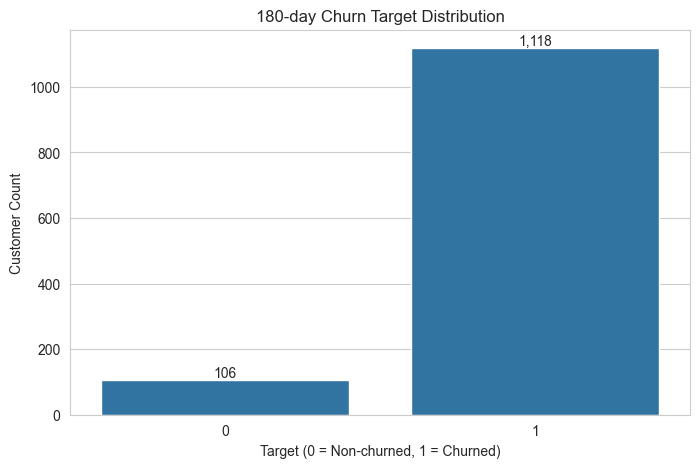

In [30]:
# Visualize selected churn target distribution

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_full, x='target')
plt.title('180-day Churn Target Distribution')
plt.xlabel('Target (0 = Non-churned, 1 = Churned)')
plt.ylabel('Customer Count')

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

### Churn Target Distribution Analysis

The distribution of ``is_churned_180d`` is highly imbalanced, with churned users making up the clear majority of the sample. This means the task is not a balanced binary classification problem, but a prediction problem under **strong class skew**. As a result, later evaluation should rely more on **precision, recall, and F1-score** than on accuracy alone.

This pattern is also meaningful from a business perspective. A high 180-day churn rate suggests that a large share of customers become inactive over a longer purchase window, so the model may capture broad disengagement patterns more easily than the smaller retained group. Therefore, the real value of the model is not simply to predict inactivity, but to identify **actionable churn risk** in a way that supports intervention.

### 2.2 Customer Lifecycle Analysis

Customer lifecycle variables help show whether churn is associated with **short customer history**, **recent inactivity**, or both. This matters because churn is not only an observed label, but also a temporal outcome shaped by how customers move through the platform over time.

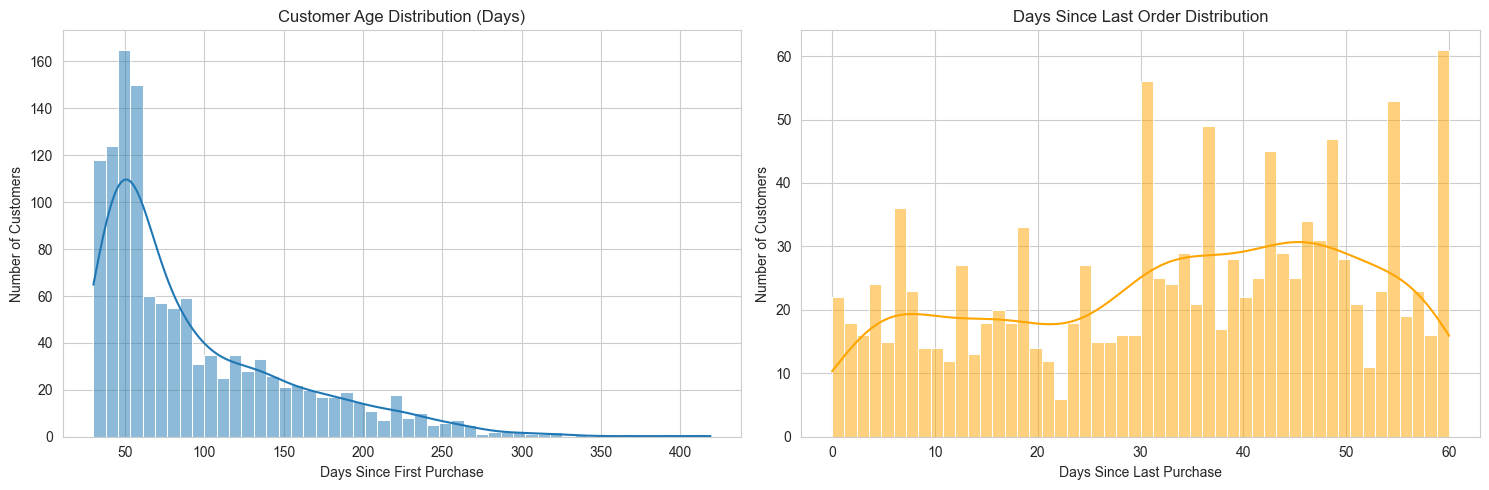

In [31]:
# Customer lifecycle analysis

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Customer age distribution
sns.histplot(df_full['customer_age_days'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Customer Age Distribution (Days)')
axes[0].set_xlabel('Days Since First Purchase')
axes[0].set_ylabel('Number of Customers')

# Days since last order distribution
sns.histplot(df_full['days_since_last_order'], bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Days Since Last Order Distribution')
axes[1].set_xlabel('Days Since Last Purchase')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### Customer Lifecycle Analysis

The lifecycle distributions show two clear patterns. ``customer_age_days`` is **right-skewed**, with many customers concentrated at lower ages and a long tail of older customers, suggesting that the sample contains many relatively new users alongside a smaller group of long-standing customers. By contrast, ``days_since_last_order`` is spread across the full range, with noticeable concentration in the **higher inactivity intervals**, which is consistent with the strong churn rate observed earlier.

This pattern is informative, but it also requires caution. Time-based variables are likely to be highly predictive, yet they may also sit very close to the churn definition itself. Therefore, their value should be interpreted critically: they capture real disengagement behaviour, but the model should not rely on them so heavily that broader behavioural signals become secondary.

### 2.3 Churned vs Active Customer Comparison

This section compares the main characteristics of **churned** and **active** customers before formal modelling. The goal is to see whether the two groups already differ in value, engagement, and service experience.

These comparisons are useful for interpretation, but they do not prove causality. Some apparent differences may reflect broader behavioural structure or the proximity between certain features and the churn definition itself.

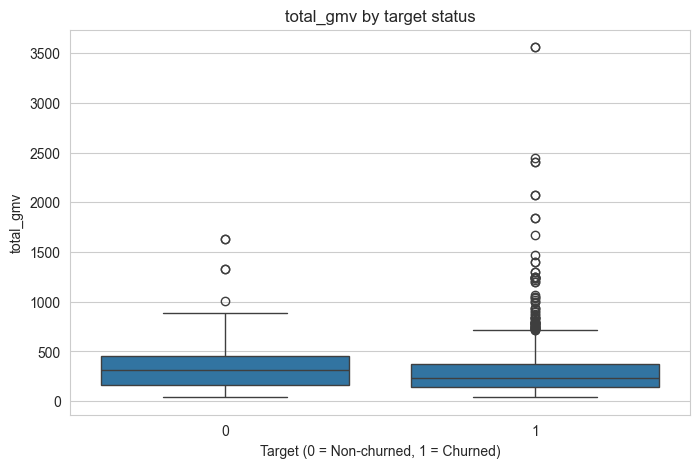

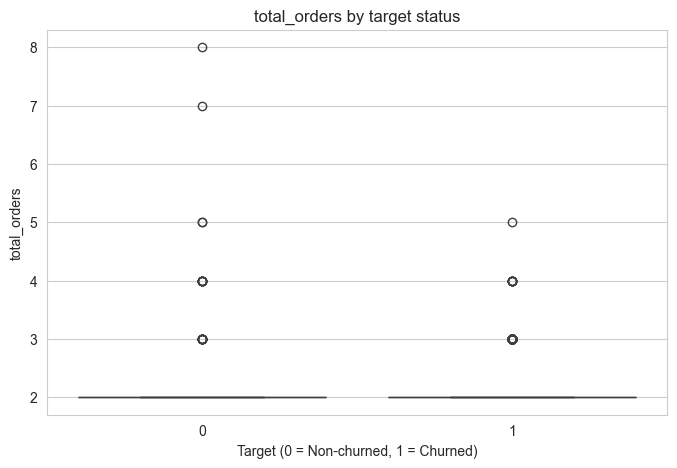

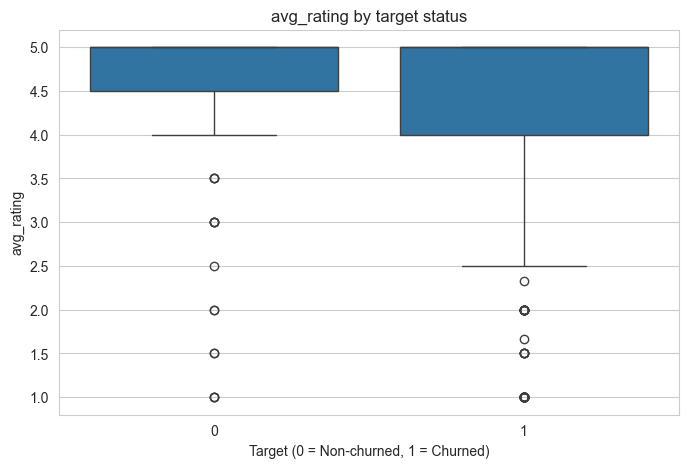

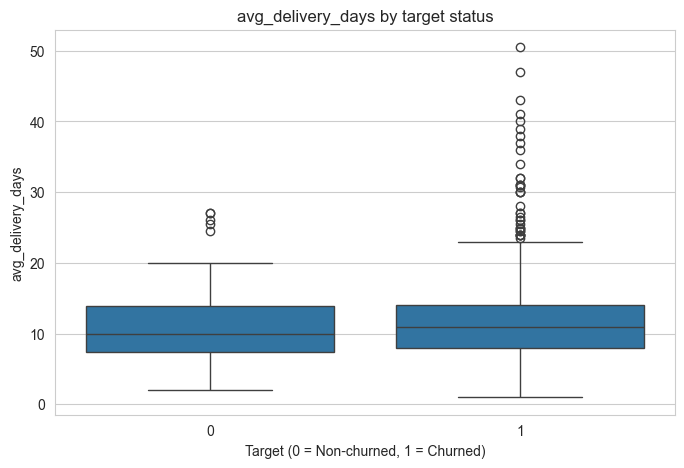

In [32]:
# Compare key feature distributions for churned vs non-churned customers

feature_list = [
    'total_gmv',
    'total_orders',
    'avg_rating',
    'avg_delivery_days'
]

for feature in feature_list:
    if feature in df_full.columns:
        plt.figure(figsize=(8, 5))
        sns.boxplot(data=df_full, x='target', y=feature)
        plt.title(f'{feature} by {target} status')
        plt.xlabel('Target (0 = Non-churned, 1 = Churned)')
        plt.ylabel(feature)
        plt.show()

### Key Feature Comparison Analysis

The visual comparison shows that the two groups are **not separated by a single feature**. ``total_gmv`` and ``total_orders`` still overlap heavily, suggesting that spending and purchase frequency alone are not enough to distinguish churned from active customers. In particular, ``total_orders`` is concentrated at low values for both groups, so its standalone signal appears limited.

By contrast, ``avg_rating`` and ``avg_delivery_days`` show more meaningful differences. Churned customers tend to have a wider spread of lower ratings, while their delivery days are slightly higher and more dispersed. This suggests that **service experience** may be more closely related to churn than pure transaction volume. Overall, the plots imply that churn is better understood as a combination of **behavioural weakness and service friction**, rather than a purely monetary outcome.

### 2.4 Correlation Heatmap

This section examines the main linear relationships among the core numeric variables. The aim is to identify potentially overlapping features, understand how strongly each variable is linearly related to the churn target, and check whether any feature may be **too close to the target definition**.

The heatmap is useful for interpretation, but it should be read critically. Correlation only captures **linear association**, so weak values do not necessarily mean a feature is unimportant, and stronger values may reflect redundancy rather than independent predictive value.

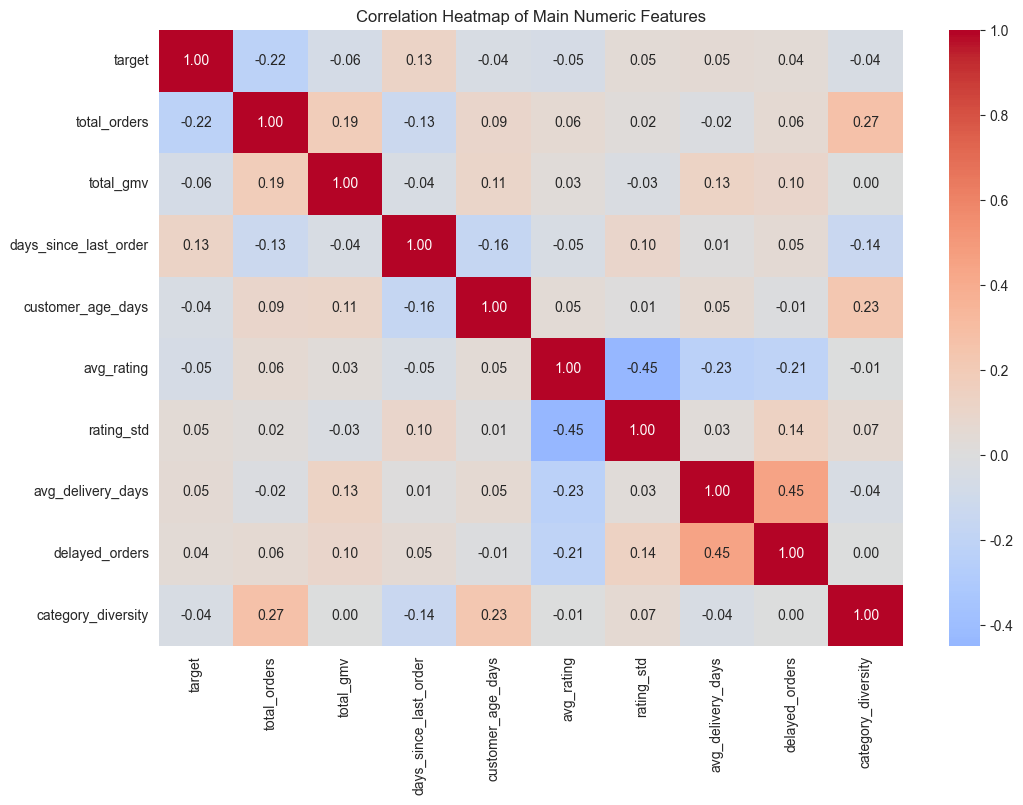

In [33]:
# Correlation heatmap for main numeric features

corr_features = [
    'target',
    'total_orders',
    'total_gmv',
    'days_since_last_order',
    'customer_age_days',
    'avg_rating',
    'rating_std',
    'avg_delivery_days',
    'delayed_orders',
    'category_diversity',
]

corr_features = [col for col in corr_features if col in df_full.columns]

corr_matrix = df_full[corr_features].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Main Numeric Features')
plt.show()

### Correlation Heatmap Analysis

The heatmap suggests that most numeric features have only **weak to moderate linear relationships** with the churn target. ``target`` is negatively correlated with ``total_orders`` and slightly positively correlated with ``days_since_last_order``, which is directionally reasonable: customers with fewer orders and longer inactivity are more likely to churn. However, the overall correlations with ``target`` are not very strong, which implies that churn is unlikely to be explained by a single numeric feature alone.

Among the predictors, a few internal relationships are more visible. ``avg_rating`` is negatively related to ``rating_std``, while ``avg_delivery_days`` is positively related to ``delayed_orders``. These patterns suggest some **feature overlap**, but not severe multicollinearity. Overall, the heatmap indicates that later modelling will likely depend more on the **combined effect of multiple weak signals** than on one dominant linear driver.

## 3. Feature Engineering

This section transforms the cleaned **snapshot-level modelling table** into a modelling-ready feature space. The aim is not simply to create more variables, but to convert raw behavioural, transactional, and service signals into features that are both **predictively useful** and **business-interpretable**.

This step also requires caution. In churn modelling, some time-based variables may look highly predictive because they are close to the target definition itself. Therefore, the feature engineering process should strengthen predictive signal while still preserving **forward-looking value** and interpretability.

### 3.1 Behaviour Features

Behaviour features extend beyond simple RFM-style summaries by describing how customers purchase over time and how much value they generate across their lifecycle. These variables are useful because churn is often linked not only to how much a customer spent, but also to **how regularly, how recently, and how efficiently they engaged**.

At the same time, behaviour features should be constructed carefully. Some may overlap with existing lifecycle or recency variables, so the goal is to improve feature richness without introducing excessive redundancy.

In [34]:
# Create a working copy for feature engineering

df_fe = df_full.copy()

# Compatibility aliases for downstream feature engineering
# These are not external RFM features; they only standardise column names
# so later code can run consistently.

if 'order_count' not in df_fe.columns and 'total_orders' in df_fe.columns:
    df_fe['order_count'] = df_fe['total_orders']

if 'total_spent' not in df_fe.columns and 'total_gmv' in df_fe.columns:
    df_fe['total_spent'] = df_fe['total_gmv']

print("df_fe created successfully.")
print("Shape:", df_fe.shape)
print(df_fe[['unique_user_id', 'total_orders', 'total_gmv']].head())

df_fe created successfully.
Shape: (1224, 52)
                     unique_user_id  total_orders  total_gmv
0  015557c9912277312b9073947804a7ba             2     315.12
1  0396c443fdda5498c7e9ed5b34871c5a             2     120.84
2  03dabd77cb0ed7a26fafe19e36b67742             2      99.45
3  06a52782a04f0086d16b9c22d0e29438             3     153.33
4  0981a271500799427cdf345e9121e20b             2     162.28


In [35]:
# Behaviour feature engineering

df_fe['days_per_order'] = df_fe['customer_age_days'] / (df_fe['order_count'] + 1)
df_fe['orders_per_month'] = df_fe['order_count'] / (df_fe['customer_age_days'] / 30 + 1)

df_fe['avg_order_value'] = df_fe['total_gmv'] / (df_fe['order_count'] + 1)
df_fe['gmv_per_day'] = df_fe['total_gmv'] / (df_fe['customer_age_days'] + 1)

df_fe['recency_ratio'] = df_fe['days_since_last_order'] / (df_fe['customer_age_days'] + 1)
df_fe['is_recent_active'] = (df_fe['days_since_last_order'] <= 30).astype(int)

print("Behaviour feature engineering completed.")
print(df_fe[[
    'customer_age_days', 'order_count', 'total_gmv',
    'days_per_order', 'orders_per_month',
    'avg_order_value', 'gmv_per_day',
    'recency_ratio', 'is_recent_active'
]].head())

Behaviour feature engineering completed.
   customer_age_days  order_count  total_gmv  days_per_order  \
0                 74            2     315.12       24.666667   
1                 31            2     120.84       10.333333   
2                 55            2      99.45       18.333333   
3                 30            3     153.33        7.500000   
4                 63            2     162.28       21.000000   

   orders_per_month  avg_order_value  gmv_per_day  recency_ratio  \
0          0.576923       105.040000     4.201600       0.466667   
1          0.983607        40.280000     3.776250       0.968750   
2          0.705882        33.150000     1.775893       0.375000   
3          1.500000        38.332500     4.946129       0.967742   
4          0.645161        54.093333     2.535625       0.765625   

   is_recent_active  
0                 0  
1                 0  
2                 1  
3                 1  
4                 0  


### Behaviour Feature Engineering Analysis

The engineered behaviour features add a more detailed view of customer activity rhythm. Variables such as ``days_per_order``, ``orders_per_month``, ``gmv_per_day``, ``recency_ratio``, and ``is_recent_active`` help describe not only how much a customer purchased, but also **how efficiently and how recently that value was generated**. This makes the feature space more informative than using raw totals alone.

However, these features should still be interpreted critically. Measures such as ``recency_ratio`` and ``is_recent_active`` are likely to be useful for prediction, but they are also relatively close to inactivity-based churn logic. Their value is therefore double-edged: they may improve discrimination, but they may also push the model toward **label-adjacent patterns** rather than broader behavioural understanding.

### 3.2 Satisfaction Features

Satisfaction features extend churn modelling beyond transaction history by capturing whether customers not only purchased, but also reported a positive post-purchase experience. Variables such as ``avg_rating``, ``rating_std``, ``bad_review_count``, ``is_satisfied``, and ``has_bad_review`` help represent the **quality and stability of customer feedback**.

At the same time, these variables should be interpreted carefully. Review data is not available for every customer, and even when it exists, e-commerce ratings are often heavily concentrated at the high end. Therefore, satisfaction features may still be useful, but their value should be judged **critically and in combination with other signals** rather than assumed to be strong on their own.

In [36]:
# Satisfaction feature engineering

satisfaction_features = ['avg_rating', 'rating_std', 'bad_review_count']

df_fe['avg_rating'] = df_fe['avg_rating'].fillna(df_fe['avg_rating'].median())
df_fe['rating_std'] = df_fe['rating_std'].fillna(0)
df_fe['bad_review_count'] = df_fe['bad_review_count'].fillna(0)

df_fe['is_satisfied'] = (df_fe['avg_rating'] >= 4).astype(int)
df_fe['has_bad_review'] = (df_fe['bad_review_count'] > 0).astype(int)

print("Satisfaction feature engineering completed.")
print(df_fe[[
    'avg_rating', 'rating_std', 'bad_review_count',
    'is_satisfied', 'has_bad_review'
]].head())

Satisfaction feature engineering completed.
   avg_rating  rating_std  bad_review_count  is_satisfied  has_bad_review
0         5.0         0.0               0.0             1               0
1         5.0         0.0               0.0             1               0
2         5.0         0.0               0.0             1               0
3         5.0         0.0               0.0             1               0
4         5.0         0.0               0.0             1               0


### Satisfaction Feature Engineering Analysis

The satisfaction features are now in a modelling-ready form. In the preview shown here, ``avg_rating`` is very high, while ``rating_std``, ``bad_review_count``, and ``has_bad_review`` show little variation. This suggests that, at least in the visible sample, satisfaction signals are relatively compressed and may provide weaker standalone separation than behavioural features.

This is still informative, but it should be interpreted with caution. A highly positive preview does not mean satisfaction is unimportant; it may simply mean that review-based variables contain **limited variance** in this dataset. Their contribution is therefore more likely to appear when combined with delivery, activity, and value-related features, rather than as a single dominant driver of churn.

### 3.3 Logistics Features

Logistics features capture whether customers experienced delivery friction after purchase. This is important because churn is often shaped not only by what customers buy, but also by whether the fulfilment process feels reliable and convenient.

Compared with review data, logistics signals are often more behaviourally grounded. However, they may still be uneven across users, so the goal here is to preserve service-quality information without letting sparse operational records distort the final feature set.

In [37]:
# Logistics feature engineering

logistics_features = ['avg_delivery_days', 'delayed_orders']

df_fe['avg_delivery_days'] = df_fe['avg_delivery_days'].fillna(df_fe['avg_delivery_days'].median())
df_fe['delayed_orders'] = df_fe['delayed_orders'].fillna(0)

df_fe['delay_rate'] = df_fe['delayed_orders'] / (df_fe['order_count'] + 1)
df_fe['has_delay'] = (df_fe['delayed_orders'] > 0).astype(int)

print("Logistics feature engineering completed.")
print(df_fe[[
    'avg_delivery_days', 'delayed_orders',
    'delay_rate', 'has_delay'
]].head())

Logistics feature engineering completed.
   avg_delivery_days  delayed_orders  delay_rate  has_delay
0               13.0             0.0         0.0          0
1               13.5             0.0         0.0          0
2               19.5             0.0         0.0          0
3               11.0             0.0         0.0          0
4               12.5             0.0         0.0          0


### Logistics Feature Engineering Analysis

The logistics features are now ready for modelling. In this sample, `avg_delivery_days` shows visible variation, while `delayed_orders`, `delay_rate`, and `has_delay` are all zero, suggesting that delivery duration may retain more information here than explicit delay-event counts.

This also indicates that logistics signals may be unevenly distributed across users. If delay-related variables remain sparse in the full sample, their standalone effect may be limited, but they can still add value when combined with satisfaction and geographic features.

### 3.4 Geographic Features

Geographic features help represent the broader market environment in which a customer shops. They are useful because churn may depend not only on individual behaviour, but also on regional differences in logistics quality, market maturity, and local customer profiles.

At the same time, geography should usually be treated as a contextual signal rather than a direct behavioural driver. The goal here is to preserve regional information in a model-friendly form without overstating its standalone explanatory power.

In [38]:
# Geographic feature engineering

le_state = LabelEncoder()
df_fe['state_encoded'] = le_state.fit_transform(df_fe['customer_state'].fillna('Unknown'))

print("Geographic feature engineering completed.")
print(df_fe[[
    'customer_state',
    'state_encoded'
]].head())

Geographic feature engineering completed.
  customer_state  state_encoded
0             SP             23
1             MG              9
2             CE              4
3             MS             10
4             RS             20


### Geographic Feature Engineering Analysis

The geographic features have now been converted into a model-ready form using `customer_state` and its encoded representation. This preserves basic regional context without introducing a separate clustering layer that has not yet been rebuilt under the same snapshot logic.

These features remain contextual rather than behavioural. They may still improve model performance by capturing broad regional differences, but later interpretation should avoid treating encoded geography as a direct cause of churn.

### 3.5 Category Preference Features

Category preference features describe what kinds of products customers tend to buy and how broad their purchasing interests are. These variables are useful because churn may differ between customers who repeatedly buy from one narrow category and those who engage across multiple categories.

This step is also important because category data originally came at the `user-category` level rather than the customer level required for modelling. The goal here is to turn those purchase patterns into stable user-level signals without inflating the feature space unnecessarily.

In [39]:
# Category preference feature check and selection

category_feature_cols = [
    col for col in df_fe.columns
    if col.startswith('cat_purchase_') or col.startswith('cat_gmv_')
]

category_summary_cols = [
    col for col in ['category_diversity', 'total_category_purchases', 'total_category_gmv']
    if col in df_fe.columns
]

selected_category_features = category_summary_cols + category_feature_cols

print("Category preference feature engineering completed.")
print(f"Number of category summary features: {len(category_summary_cols)}")
print(f"Number of category one-hot / aggregated features: {len(category_feature_cols)}")
print(f"Total category-related features: {len(selected_category_features)}")

df_fe[['unique_user_id'] + selected_category_features[:10]].head()

Category preference feature engineering completed.
Number of category summary features: 3
Number of category one-hot / aggregated features: 20
Total category-related features: 23


,unique_user_id,category_diversity,total_category_purchases,total_category_gmv,cat_purchase_beleza_saude,cat_purchase_brinquedos,cat_purchase_cama_mesa_banho,cat_purchase_esporte_lazer,cat_purchase_fashion_bolsas_e_acessorios,cat_purchase_informatica_acessorios,cat_purchase_moveis_decoracao
0,015557c9912277312b9073947804a7ba,2,2,315.12,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0396c443fdda5498c7e9ed5b34871c5a,1,2,120.84,0.0,0.0,2.0,0.0,0.0,0.0,0.0
2,03dabd77cb0ed7a26fafe19e36b67742,1,2,99.45,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,06a52782a04f0086d16b9c22d0e29438,1,3,153.33,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0981a271500799427cdf345e9121e20b,1,2,162.28,2.0,0.0,0.0,0.0,0.0,0.0,0.0


### Category Preference Feature Engineering Analysis

The category preference features are now available in a compact user-level form. The mix of summary variables such as `category_diversity` and more specific `cat_purchase_*` / `cat_gmv_*` features helps preserve both **breadth of interest** and **category-level purchasing intensity**.

At the same time, these variables should be interpreted with some caution. Category signals can enrich the model, but they may also be sparse for less active users, so their value is likely to come from how they interact with spending and behaviour features rather than from acting as a dominant signal on their own.
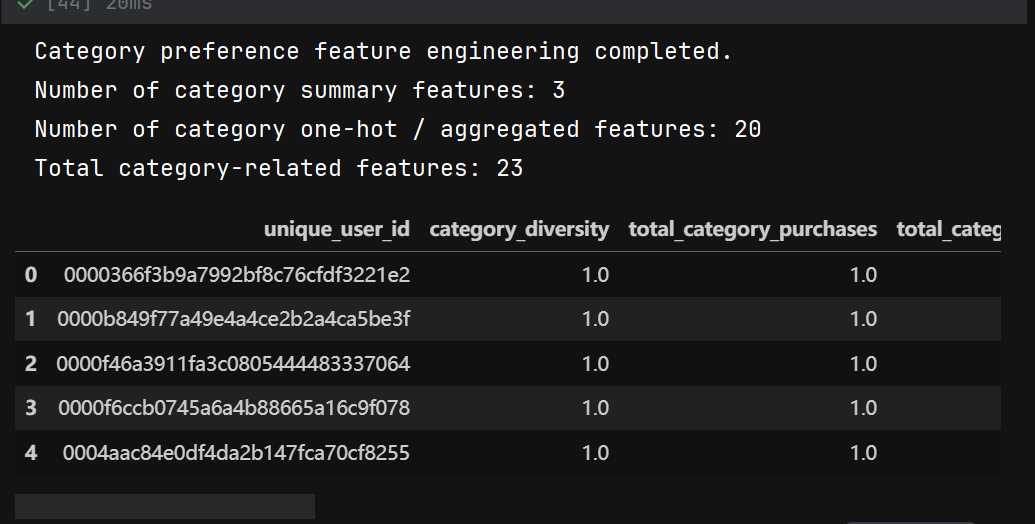

### 3.6 Time Features

Time features help preserve seasonality and customer timing patterns that may not be captured by aggregate spending or frequency alone. They are useful because customers who entered the platform in different periods, or who purchased in different seasonal windows, may show different retention behaviour.

However, time variables need careful interpretation. Some date-based fields can be informative without being problematic, while others may overlap too closely with the churn label. This step therefore focuses on simple calendar-based features that are easy to interpret and easy to reuse later.

In [40]:
# Time feature engineering

df_fe['first_purchase_date'] = pd.to_datetime(df_fe['first_purchase_date'], errors='coerce')
df_fe['last_purchase_date'] = pd.to_datetime(df_fe['last_purchase_date'], errors='coerce')

df_fe['first_purchase_month'] = df_fe['first_purchase_date'].dt.month
df_fe['first_purchase_quarter'] = df_fe['first_purchase_date'].dt.quarter

df_fe['last_purchase_month'] = df_fe['last_purchase_date'].dt.month
df_fe['last_purchase_quarter'] = df_fe['last_purchase_date'].dt.quarter

print("Time feature engineering completed.")
print(df_fe[[
    'first_purchase_date', 'last_purchase_date',
    'first_purchase_month', 'first_purchase_quarter',
    'last_purchase_month', 'last_purchase_quarter'
]].head())

Time feature engineering completed.
  first_purchase_date  last_purchase_date  first_purchase_month  \
0 2017-03-23 22:45:46 2017-05-01 14:48:33                     3   
1 2017-05-05 08:44:57 2017-05-05 08:44:58                     5   
2 2017-04-11 18:19:55 2017-05-15 10:14:17                     4   
3 2017-05-06 20:11:10 2017-05-06 20:11:11                     5   
4 2017-04-03 13:57:14 2017-04-17 10:05:11                     4   

   first_purchase_quarter  last_purchase_month  last_purchase_quarter  
0                       1                    5                      2  
1                       2                    5                      2  
2                       2                    5                      2  
3                       2                    5                      2  
4                       2                    4                      2  


### Time Feature Engineering Analysis

The time features have been successfully converted into simple calendar variables. `first_purchase_month` and `first_purchase_quarter` help capture when customers entered the platform, while the corresponding last-purchase fields retain recent timing information in a more interpretable form than raw timestamps.

These features are lightweight but useful. They are less likely to dominate the model than direct inactivity measures, yet they can still capture seasonal or cohort-related patterns that may help explain differences in retention.

### 3.7 Final Feature Set

This section consolidates all engineered variables into a single candidate feature list for modelling. The aim is to keep the feature space broad enough to capture customer value, service experience, regional context, and product preference, while still making the final modelling table easy to inspect and validate.

At this stage, the goal is to define a **complete candidate set**, not to make the final judgement about feature usefulness. The later modelling stage will determine which features are most informative, which are redundant, and which may need to be treated cautiously because of their closeness to the target construction.

In [41]:
# Final Feature Set (current snapshot-safe version)

behaviour_features = [
    col for col in [
        'avg_order_value', 'gmv_per_day', 'days_per_order',
        'orders_per_month', 'recency_ratio', 'is_recent_active',
        'total_orders', 'total_gmv', 'days_since_last_order',
        'customer_age_days'
    ]
    if col in df_fe.columns
]

satisfaction_features = [
    col for col in [
        'avg_rating', 'rating_std', 'bad_review_count',
        'is_satisfied', 'has_bad_review'
    ]
    if col in df_fe.columns
]

logistics_features = [
    col for col in [
        'avg_delivery_days', 'delayed_orders',
        'delay_rate', 'has_delay'
    ]
    if col in df_fe.columns
]

time_features = [
    col for col in [
        'first_purchase_month', 'first_purchase_quarter',
        'last_purchase_month', 'last_purchase_quarter'
    ]
    if col in df_fe.columns
]

category_summary_features = [
    col for col in [
        'category_diversity', 'total_category_purchases', 'total_category_gmv'
    ]
    if col in df_fe.columns
]

purchase_cat_cols = [c for c in df_fe.columns if c.startswith('cat_purchase_')]
gmv_cat_cols = [c for c in df_fe.columns if c.startswith('cat_gmv_')]

top_purchase_cats = []
top_gmv_cats = []

if len(purchase_cat_cols) > 0:
    top_purchase_cats = (
        df_fe[purchase_cat_cols].sum()
        .sort_values(ascending=False)
        .head(5)
        .index.tolist()
    )

if len(gmv_cat_cols) > 0:
    top_gmv_cats = (
        df_fe[gmv_cat_cols].sum()
        .sort_values(ascending=False)
        .head(5)
        .index.tolist()
    )

category_features = category_summary_features + top_purchase_cats + top_gmv_cats

categorical_features = [
    col for col in [
        'customer_state',
        'dominant_category'
    ]
    if col in df_fe.columns
]

feature_columns = (
    behaviour_features +
    satisfaction_features +
    logistics_features +
    time_features +
    category_features +
    categorical_features
)

feature_columns = list(dict.fromkeys(feature_columns))

numeric_feature_columns = [
    c for c in feature_columns
    if pd.api.types.is_numeric_dtype(df_fe[c])
]

corr_matrix = df_fe[numeric_feature_columns].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.90)]

numeric_feature_columns = [c for c in numeric_feature_columns if c not in to_drop_corr]
categorical_feature_columns = [c for c in feature_columns if c not in numeric_feature_columns]

feature_columns = numeric_feature_columns + categorical_feature_columns

print("Final feature set summary")
print("-" * 50)
print(f"Behaviour features   : {len([c for c in feature_columns if c in behaviour_features])}")
print(f"Satisfaction features: {len([c for c in feature_columns if c in satisfaction_features])}")
print(f"Logistics features   : {len([c for c in feature_columns if c in logistics_features])}")
print(f"Time features        : {len([c for c in feature_columns if c in time_features])}")
print(f"Category features    : {len([c for c in feature_columns if c in category_features])}")
print(f"Categorical features : {len([c for c in feature_columns if c in categorical_features])}")
print(f"Total features       : {len(feature_columns)}")

missing_final = df_fe[feature_columns].isnull().sum()
missing_final = missing_final[missing_final > 0].sort_values(ascending=False)

if len(missing_final) > 0:
    print("\nWarning: missing values still exist in final feature set")
    print(missing_final)
else:
    print("\n✓ No missing values in final feature set")

print("\nDropped by high correlation (>0.90):")
print(to_drop_corr if len(to_drop_corr) > 0 else "None")

print("\nSample feature columns:")
print(feature_columns[:25])

Final feature set summary
--------------------------------------------------
Behaviour features   : 10
Satisfaction features: 5
Logistics features   : 4
Time features        : 4
Category features    : 13
Categorical features : 2
Total features       : 38

✓ No missing values in final feature set

Dropped by high correlation (>0.90):
['total_gmv', 'customer_age_days', 'has_bad_review', 'delay_rate', 'has_delay', 'first_purchase_quarter', 'last_purchase_quarter', 'total_category_gmv', 'cat_gmv_informatica_acessorios']

Sample feature columns:
['avg_order_value', 'gmv_per_day', 'days_per_order', 'orders_per_month', 'recency_ratio', 'is_recent_active', 'total_orders', 'days_since_last_order', 'avg_rating', 'rating_std', 'bad_review_count', 'is_satisfied', 'avg_delivery_days', 'delayed_orders', 'first_purchase_month', 'last_purchase_month', 'category_diversity', 'total_category_purchases', 'cat_purchase_cama_mesa_banho', 'cat_purchase_moveis_decoracao', 'cat_purchase_esporte_lazer', 'cat_pu

### Final Feature Set Analysis

The final feature set contains **38 candidate variables** across behaviour, satisfaction, logistics, time, category, and categorical context. This means the model will not rely on a single dimension of churn, but on a broader combination of **customer activity**, **service experience**, and **purchase structure**.

Another positive result is that the final feature matrix contains **no missing values**, which makes the downstream modelling process cleaner and more stable. However, a complete feature set should not automatically be treated as an optimal one. Some variables may still be redundant, weak, or too close to the target logic. Therefore, the next modelling stage is important not only for prediction, but also for testing which features provide **genuine explanatory value** rather than superficial signal.

## 4. Data Preprocessing

This section prepares the engineered feature table for model training. The purpose is not only to separate predictors from the target, but also to make sure that the modelling setup is consistent with the business objective and statistically appropriate for the class structure observed earlier.

In churn prediction, preprocessing decisions matter because they directly affect how performance should be interpreted. A technically correct pipeline can still produce misleading results if the target is poorly chosen, if feature scaling is inconsistent, or if class imbalance is handled in a way that does not match the actual data structure.

### 4.1 Target Variable Selection

The project defines churn under multiple inactivity windows, including ``30d``, ``60d``, ``90d``, ``180d``, and ``270d``. In the current pipeline, ``is_churned_180d`` is selected as the main target because it provides a more stable definition of disengagement while still preserving business relevance.

A shorter window may respond too strongly to temporary inactivity, while a longer window can better capture **sustained churn behaviour**. However, this also creates a trade-off: a more stable target may improve modelling consistency, but it may reduce the timeliness of intervention. The chosen target should therefore be interpreted as a balance between **stability** and **actionability**.

### Label Diagnostic Check

Before continuing to model training, the churn labels need to be validated against the observation window. This step checks whether the label construction is temporally consistent and whether the observed class balance reflects a plausible business pattern rather than a view-definition problem.

In churn prediction, a label that is technically available is not always a valid modelling target. If the observation date and purchase history are not aligned correctly, later model performance may look strong while the underlying prediction task is mis-specified.

In [42]:
print("Unique obs_date count:", df_fe['obs_date'].nunique())
print("Observation date range:", pd.to_datetime(df_fe['obs_date']).min(), "to", pd.to_datetime(df_fe['obs_date']).max())
print("Last purchase range:", pd.to_datetime(df_fe['last_purchase_date']).min(), "to", pd.to_datetime(df_fe['last_purchase_date']).max())
print("First purchase range:", pd.to_datetime(df_fe['first_purchase_date']).min(), "to", pd.to_datetime(df_fe['first_purchase_date']).max())

target_check = pd.DataFrame({
    'target': ['is_churned_30d', 'is_churned_60d', 'is_churned_90d', 'is_churned_180d', 'is_churned_270d'],
    'churn_rate': [
        df_fe['is_churned_30d'].mean() if 'is_churned_30d' in df_fe.columns else np.nan,
        df_fe['is_churned_60d'].mean() if 'is_churned_60d' in df_fe.columns else np.nan,
        df_fe['is_churned_90d'].mean() if 'is_churned_90d' in df_fe.columns else np.nan,
        df_fe['is_churned_180d'].mean() if 'is_churned_180d' in df_fe.columns else np.nan,
        df_fe['is_churned_270d'].mean() if 'is_churned_270d' in df_fe.columns else np.nan
    ]
})
print(target_check)

Unique obs_date count: 7
Observation date range: 2017-06-05 15:00:37 to 2017-12-02 15:00:37
Last purchase range: 2017-04-06 13:45:15 to 2017-12-02 10:36:19
First purchase range: 2016-10-03 09:44:50 to 2017-11-02 15:17:45
            target  churn_rate
0   is_churned_30d    0.970588
1   is_churned_60d    0.955065
2   is_churned_90d    0.947712
3  is_churned_180d    0.913399
4  is_churned_270d    0.897876


In [43]:
# Select the main target variable

target = 'target'

print("Target variable selected:", target)
print(f"Churn rate: {df_fe[target].mean():.2%}")
print(f"Churned users: {int(df_fe[target].sum())}")
print(f"Active users: {int((df_fe[target] == 0).sum())}")

# Final check: target should not be null
assert df_fe[target].isnull().sum() == 0, "Null values detected in target variable"

Target variable selected: target
Churn rate: 91.34%
Churned users: 1118
Active users: 106


### Target Selection Analysis

The diagnostic results show that the churn labels are **temporally consistent** with the rolling observation framework: there are ``7`` distinct observation dates, and the ranges of first purchase, last purchase, and observation date follow a logical sequence. This suggests that the target construction is structurally sound and does not appear to suffer from obvious timestamp misalignment.

At the same time, the label comparison reveals that **all churn windows are highly imbalanced**, with churn rates remaining extremely high even at ``180d`` and ``270d``. After selecting ``is_churned_180d`` as the final target, the dataset still contains ``1,118`` churned observations and only ``106`` active ones, which confirms that the modelling task is heavily skewed toward the churn class. This is an important reflection point: the target is valid and business-meaningful, but the resulting classification problem is difficult in a different way from standard churn modelling. Later evaluation must therefore focus on whether the model can identify **useful retention signals** within a very small active group, rather than relying on accuracy alone.

### 4.2 Train/Test Split

This step separates the modelling table into training and test sets using a **user-level grouped split**. The purpose is not only to create a holdout set, but also to ensure that the same customer does not appear in both subsets, which is especially important in a rolling-snapshot churn setting.

This design makes the evaluation more reliable because it reduces **user-level leakage**. In churn modelling, a random row-level split may produce overly optimistic results if repeated observations from the same customer are shared across train and test data.

In [44]:
from sklearn.model_selection import GroupShuffleSplit

X = df_fe[feature_columns].copy()
y = df_fe[target].copy()
groups = df_fe['unique_user_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print(f"Train churn rate: {y_train.mean():.2%}")
print(f"Test churn rate : {y_test.mean():.2%}")
print("Train unique users:", df_fe.iloc[train_idx]['unique_user_id'].nunique())
print("Test unique users :", df_fe.iloc[test_idx]['unique_user_id'].nunique())
print(
    "Overlap users:",
    len(
        set(df_fe.iloc[train_idx]['unique_user_id']).intersection(
            set(df_fe.iloc[test_idx]['unique_user_id'])
        )
    )
)

Train shape: (932, 38)
Test shape : (292, 38)
Train churn rate: 91.95%
Test churn rate : 89.38%
Train unique users: 622
Test unique users : 208
Overlap users: 0


### Train/Test Split Analysis

The split results show that the preprocessing strategy is structurally sound. The training set contains ``932`` rows and the test set contains ``292`` rows, while the numbers of unique users are ``622`` and ``208`` respectively. Most importantly, the overlap in ``unique_user_id`` is **0**, which confirms that the train/test split successfully prevents the same customer from appearing in both datasets.

The churn rates remain high in both subsets, although they are not exactly identical: the training set has a churn rate of **91.95%**, while the test set has **89.38%**. This difference is acceptable, but it also reminds us that in a small and highly imbalanced dataset, even a correct split may still produce some distribution shift. Therefore, the value of this step is not only technical separation, but also a more honest evaluation setting in which model performance is less likely to be inflated by repeated-user leakage.

### 4.3 Feature Standardisation and Encoding

The final feature table contains both numeric and categorical variables, so preprocessing needs to treat them differently. Numeric features are imputed and scaled, while categorical features are imputed and one-hot encoded.

This setup is more robust than forcing all inputs into a single numeric workflow, because it preserves categorical information without introducing arbitrary ordinal meaning.

In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features_final = [c for c in feature_columns if pd.api.types.is_numeric_dtype(df_fe[c])]
categorical_features_final = [c for c in feature_columns if c not in numeric_features_final]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_final),
        ('cat', categorical_transformer, categorical_features_final)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Numeric features:", len(numeric_features_final))
print("Categorical features:", len(categorical_features_final))
print("Processed train shape:", X_train_processed.shape)
print("Processed test shape :", X_test_processed.shape)

Numeric features: 36
Categorical features: 2
Processed train shape: (932, 104)
Processed test shape : (292, 104)


### Feature Standardisation and Encoding Analysis

The preprocessing results show that the final feature space contains **36 numeric features** and **2 categorical features**. After scaling and one-hot encoding, the training and test sets expand to **104 processed features**, which means the categorical information has been successfully preserved in a model-ready form.

This is a useful transformation, but it also introduces a trade-off. A richer encoded feature space can improve model flexibility, yet it also increases dimensionality relative to the sample size. Therefore, this step makes the data technically ready for modelling, while also highlighting the need to interpret later model performance carefully and watch for possible overfitting.

### 4.4 Imbalance Handling

The selected churn target remains **highly imbalanced**, so the modelling pipeline needs to address class skew explicitly rather than relying on default model settings. In this project, the majority class is the churned group, while the active-user group is much smaller.

This is an important detail because imbalance handling should follow the **actual class structure** of the data, not the usual assumption that the positive class is always the minority. Therefore, resampling is used here to make the training data more balanced before model fitting.

In [46]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

class_counts = y_train.value_counts().sort_index()
imbalance_ratio = class_counts.max() / class_counts.min()

print("Class distribution in training set:")
print(class_counts)
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

X_train_balanced = X_train_processed
y_train_balanced = y_train.copy()

if imbalance_ratio >= 3.0:
    smote = SMOTE(
        sampling_strategy=0.7,
        random_state=42,
        k_neighbors=5
    )
    X_smote, y_smote = smote.fit_resample(X_train_processed, y_train)

    undersampler = RandomUnderSampler(
        sampling_strategy=0.9,
        random_state=42
    )
    X_train_balanced, y_train_balanced = undersampler.fit_resample(X_smote, y_smote)

    print("\nAfter SMOTE + RandomUnderSampler:")
    print(pd.Series(y_train_balanced).value_counts().sort_index())
else:
    print("\nImbalance level is acceptable. No resampling applied.")
    print("\nImbalance level is acceptable. No resampling applied.")

Class distribution in training set:
target
0     75
1    857
Name: count, dtype: int64
Imbalance ratio: 11.43:1

After SMOTE + RandomUnderSampler:
target
0    599
1    665
Name: count, dtype: int64


### Imbalance Handling Analysis

The class distribution before resampling confirms that the training data is **severely imbalanced**, with only ``75`` active observations versus ``857`` churned observations, corresponding to an imbalance ratio of about **11.43:1**. This means that, without correction, a model could achieve superficially strong performance simply by predicting the majority churn class.

After applying ``SMOTE`` and ``RandomUnderSampler``, the class distribution becomes much more balanced at ``599`` versus ``665``. This provides a fairer basis for model learning, especially for identifying the smaller active group. However, this step should still be interpreted critically: resampling can improve class balance, but it may also alter the original data structure. Therefore, later evaluation on the untouched test set remains essential for judging whether the model has learned **useful churn patterns** rather than only adapting to the resampled training data.

## 5. Model Training

This chapter trains and compares multiple classification models for churn prediction. The goal is not only to maximise predictive performance, but also to understand how different model families respond to the same feature space and class structure.

Because the dataset is highly imbalanced and built from repeated customer snapshots, model performance should be interpreted carefully. A strong result is meaningful only if it remains robust under the current **grouped split**, preprocessing pipeline, and leakage-controlled design.

### 5.1 Logistic Regression Baseline

Logistic Regression is used as the first baseline model because it is simple, transparent, and easy to interpret. Although it may not capture complex non-linear churn patterns, it provides a useful reference point for judging whether later tree-based or boosting models genuinely add predictive value.

It is also a good diagnostic model. If a simple linear classifier already performs strongly, that suggests the engineered features contain meaningful signal; if not, later performance gains may come more from model flexibility than from feature quality alone.

In [47]:
# 5.1 Logistic Regression Baseline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, accuracy_score
)

# Use the resampled training set created in 4.4
X_train_model = X_train_balanced
y_train_model = y_train_balanced

# Test set must remain untouched
X_test_model = X_test_processed
y_test_model = y_test.copy()

lr_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train_model, y_train_model)

# Predictions
y_pred_lr = lr_model.predict(X_test_model)
y_proba_lr = lr_model.predict_proba(X_test_model)[:, 1]

# Metrics
lr_auc = roc_auc_score(y_test_model, y_proba_lr)
lr_f1 = f1_score(y_test_model, y_pred_lr)
lr_precision = precision_score(y_test_model, y_pred_lr, zero_division=0)
lr_recall = recall_score(y_test_model, y_pred_lr, zero_division=0)
lr_accuracy = accuracy_score(y_test_model, y_pred_lr)

print("Logistic Regression Results")
print("-" * 50)
print(f"AUC        : {lr_auc:.4f}")
print(f"F1-score   : {lr_f1:.4f}")
print(f"Precision  : {lr_precision:.4f}")
print(f"Recall     : {lr_recall:.4f}")
print(f"Accuracy   : {lr_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test_model,
    y_pred_lr,
    target_names=['Active', 'Churned'],
    zero_division=0
))

cm_lr = confusion_matrix(y_test_model, y_pred_lr)
print("\nConfusion Matrix:")
print(cm_lr)

Logistic Regression Results
--------------------------------------------------
AUC        : 0.5645
F1-score   : 0.8430
Precision  : 0.9148
Recall     : 0.7816
Accuracy   : 0.7397

Classification Report:
              precision    recall  f1-score   support

      Active       0.17      0.39      0.24        31
     Churned       0.91      0.78      0.84       261

    accuracy                           0.74       292
   macro avg       0.54      0.58      0.54       292
weighted avg       0.84      0.74      0.78       292


Confusion Matrix:
[[ 12  19]
 [ 57 204]]


### Logistic Regression Analysis

The Logistic Regression baseline delivers a **mixed result**. On the surface, the model achieves a relatively high **F1-score (0.8430)**, **precision (0.9148)**, and **accuracy (0.7397)**. However, these values need to be interpreted carefully because the test set is heavily dominated by churned users. In this context, strong overall scores do not necessarily mean that the model is performing well across both classes.

A more critical reading shows that the model has **limited discriminative power**, with an **AUC of only 0.5645**. This suggests that the model is only slightly better than random ranking when separating churned and active users. The classification report also shows weak performance for the **Active** class: only **12 out of 31** active users are correctly identified, and the active-user recall is only **0.39**. In practice, this means the model is still much better at recognising the dominant churn group than at preserving the smaller retained group.

This result is useful as a baseline, but it also reveals an important limitation. A simple linear model can capture part of the broad churn pattern, yet it struggles to represent the more subtle structure needed to distinguish active users from churned users in such an imbalanced dataset. Therefore, the next step is not just to seek higher scores, but to test whether more flexible non-linear models can provide **genuinely better separation**, especially for the minority active group.

### 5.2 Random Forest

Random Forest is used as the first non-linear model in this project. Compared with Logistic Regression, it can capture more complex interactions across behavioural, satisfaction, logistics, geographic, and category-related features without requiring a strictly linear relationship with churn.

This makes it a useful next step after the baseline model. If Random Forest performs better, that would suggest the churn process is shaped by **non-linear and interacting signals** rather than by simple additive effects alone.

In [48]:
# 5.2 Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, accuracy_score
)

# Use the same training and test data as the Logistic Regression baseline
X_train_model = X_train_balanced
y_train_model = y_train_balanced

X_test_model = X_test_processed
y_test_model = y_test.copy()

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_model, y_train_model)

# Predictions
y_pred_rf = rf_model.predict(X_test_model)
y_proba_rf = rf_model.predict_proba(X_test_model)[:, 1]

# Metrics
rf_auc = roc_auc_score(y_test_model, y_proba_rf)
rf_f1 = f1_score(y_test_model, y_pred_rf)
rf_precision = precision_score(y_test_model, y_pred_rf, zero_division=0)
rf_recall = recall_score(y_test_model, y_pred_rf, zero_division=0)
rf_accuracy = accuracy_score(y_test_model, y_pred_rf)

print("Random Forest Results")
print("-" * 50)
print(f"AUC        : {rf_auc:.4f}")
print(f"F1-score   : {rf_f1:.4f}")
print(f"Precision  : {rf_precision:.4f}")
print(f"Recall     : {rf_recall:.4f}")
print(f"Accuracy   : {rf_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test_model,
    y_pred_rf,
    target_names=['Active', 'Churned'],
    zero_division=0
))

cm_rf = confusion_matrix(y_test_model, y_pred_rf)
print("\nConfusion Matrix:")
print(cm_rf)

Random Forest Results
--------------------------------------------------
AUC        : 0.5729
F1-score   : 0.9316
Precision  : 0.9000
Recall     : 0.9655
Accuracy   : 0.8733

Classification Report:
              precision    recall  f1-score   support

      Active       0.25      0.10      0.14        31
     Churned       0.90      0.97      0.93       261

    accuracy                           0.87       292
   macro avg       0.57      0.53      0.54       292
weighted avg       0.83      0.87      0.85       292


Confusion Matrix:
[[  3  28]
 [  9 252]]


### Random Forest Analysis

Random Forest improves the overall classification results, with **higher accuracy (0.8733)** and **very high churn recall (0.9655)**. This suggests that the model is better than Logistic Regression at capturing the dominant churn pattern in the data.

However, the improvement is still uneven. The **AUC is only 0.5729**, and the model identifies only **3 out of 31** active users correctly. This means Random Forest is still heavily biased toward the majority churn class. In other words, it predicts churn well, but it does **not separate the minority active group effectively**.

This result is still useful. It suggests that non-linear structure exists, but the current data imbalance and target design continue to limit discrimination. The next step is to test whether boosting models can produce **better ranking ability**, not just stronger majority-class prediction.

### 5.3 XGBoost

XGBoost is introduced as a stronger boosting model that can capture more complex non-linear relationships and feature interactions than Random Forest. It is often effective in tabular prediction tasks, especially when the signal is distributed across many weak or moderately useful features.

In this project, XGBoost is important because the earlier models already showed that simple improvement in accuracy is not enough. The key question is whether a stronger model can provide **better class separation**, especially for the smaller active-user group.

In [49]:
# 5.3 XGBoost

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, accuracy_score
)

X_train_model = X_train_balanced
y_train_model = y_train_balanced

X_test_model = X_test_processed
y_test_model = y_test.copy()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_model, y_train_model)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_model)
y_proba_xgb = xgb_model.predict_proba(X_test_model)[:, 1]

# Metrics
xgb_auc = roc_auc_score(y_test_model, y_proba_xgb)
xgb_f1 = f1_score(y_test_model, y_pred_xgb)
xgb_precision = precision_score(y_test_model, y_pred_xgb, zero_division=0)
xgb_recall = recall_score(y_test_model, y_pred_xgb, zero_division=0)
xgb_accuracy = accuracy_score(y_test_model, y_pred_xgb)

print("XGBoost Results")
print("-" * 50)
print(f"AUC        : {xgb_auc:.4f}")
print(f"F1-score   : {xgb_f1:.4f}")
print(f"Precision  : {xgb_precision:.4f}")
print(f"Recall     : {xgb_recall:.4f}")
print(f"Accuracy   : {xgb_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test_model,
    y_pred_xgb,
    target_names=['Active', 'Churned'],
    zero_division=0
))

cm_xgb = confusion_matrix(y_test_model, y_pred_xgb)
print("\nConfusion Matrix:")
print(cm_xgb)

XGBoost Results
--------------------------------------------------
AUC        : 0.5682
F1-score   : 0.9375
Precision  : 0.9011
Recall     : 0.9770
Accuracy   : 0.8836

Classification Report:
              precision    recall  f1-score   support

      Active       0.33      0.10      0.15        31
     Churned       0.90      0.98      0.94       261

    accuracy                           0.88       292
   macro avg       0.62      0.54      0.54       292
weighted avg       0.84      0.88      0.85       292


Confusion Matrix:
[[  3  28]
 [  6 255]]


### XGBoost Analysis

XGBoost produces the strongest overall results so far in terms of **accuracy (0.8836)**, **F1-score (0.9375)**, and **churn recall (0.9770)**. This shows that the model is highly effective at identifying the dominant churn class and performs slightly better than Random Forest on the main classification metrics.

However, the deeper limitation remains unchanged. The **AUC is still only 0.5682**, and the model correctly identifies just **3 active users** out of 31. This means the model is still learning the broad churn pattern much more easily than the smaller active-user pattern. The improvement is therefore mostly in **majority-class prediction**, not in balanced discrimination.

This is an important reflection point. A more powerful model does not automatically solve the core problem of this dataset. The main difficulty is not only model choice, but also the combination of **extreme class imbalance**, **small active group size**, and a churn definition that makes inactivity very dominant.

### 5.4 LightGBM

LightGBM is used as another boosting-based model for churn prediction. Compared with XGBoost, it is often faster and can handle high-dimensional tabular features efficiently, which makes it a useful benchmark in this project.

At this stage, the purpose is not only to see whether LightGBM can outperform earlier models, but also to check whether a different boosting framework can improve the model’s ability to distinguish the small active group from the dominant churn group.

In [50]:
# 5.4 LightGBM

from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, accuracy_score
)

X_train_model = X_train_balanced
y_train_model = y_train_balanced

X_test_model = X_test_processed
y_test_model = y_test.copy()

lgbm_model = LGBMClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    num_leaves=15,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model.fit(X_train_model, y_train_model)

# Predictions
y_pred_lgbm = lgbm_model.predict(X_test_model)
y_proba_lgbm = lgbm_model.predict_proba(X_test_model)[:, 1]

# Metrics
lgbm_auc = roc_auc_score(y_test_model, y_proba_lgbm)
lgbm_f1 = f1_score(y_test_model, y_pred_lgbm)
lgbm_precision = precision_score(y_test_model, y_pred_lgbm, zero_division=0)
lgbm_recall = recall_score(y_test_model, y_pred_lgbm, zero_division=0)
lgbm_accuracy = accuracy_score(y_test_model, y_pred_lgbm)

print("LightGBM Results")
print("-" * 50)
print(f"AUC        : {lgbm_auc:.4f}")
print(f"F1-score   : {lgbm_f1:.4f}")
print(f"Precision  : {lgbm_precision:.4f}")
print(f"Recall     : {lgbm_recall:.4f}")
print(f"Accuracy   : {lgbm_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test_model,
    y_pred_lgbm,
    target_names=['Active', 'Churned'],
    zero_division=0
))

cm_lgbm = confusion_matrix(y_test_model, y_pred_lgbm)
print("\nConfusion Matrix:")
print(cm_lgbm)

[LightGBM] [Info] Number of positive: 665, number of negative: 599
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001876 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4704
[LightGBM] [Info] Number of data points in the train set: 1264, number of used features: 69
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.526108 -> initscore=0.104525
[LightGBM] [Info] Start training from score 0.104525
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

### LightGBM Analysis

LightGBM achieves the highest **accuracy (0.8904)**, **F1-score (0.9414)**, and **churn recall (0.9847)** among the four models so far. This means it is very effective at identifying the dominant churn class and performs slightly better than XGBoost on the main classification metrics.

However, the broader pattern still does not change. The **AUC drops to 0.5253**, and the model correctly identifies only **3 active users** out of 31. This suggests that the model is becoming even more concentrated on the majority churn class, rather than improving real separation between churned and active users.

This is a useful but cautionary result. Better headline metrics do not necessarily mean a better churn model. In the current dataset, stronger models are mostly improving **majority-class fit**, while the smaller active-user group remains difficult to capture. This means later model selection should focus on **balanced discrimination and business usefulness**, not only on accuracy or F1-score.

## 6. Model Comparison and Selection

This chapter compares the trained models from a common evaluation perspective. The purpose is not only to rank models by performance, but also to examine whether higher headline scores reflect **genuine class separation** or simply stronger prediction of the dominant churn class.

In an imbalanced churn setting, model comparison should be interpreted carefully. A model with the highest accuracy or F1-score is not automatically the most useful if it still performs poorly on the smaller active-user group.

### 6.1 Model Performance Comparison

This section summarises the main performance metrics of the four trained models, including **AUC**, **F1-score**, **precision**, **recall**, and **accuracy**. A compact comparison table is useful because no single metric is sufficient for model selection in this project.

To make the comparison more intuitive, the results are also visualised. This helps show whether a model is consistently strong across metrics, or whether its apparent advantage comes mainly from fitting the dominant churn class.

,Model,AUC,F1-score,Precision,Recall,Accuracy
1,Random Forest,0.572859,0.931608,0.900000,0.965517,0.873288
2,XGBoost,0.568162,0.937500,0.901060,0.977011,0.883562
0,Logistic Regression,0.564454,0.842975,0.914798,0.781609,0.739726
3,LightGBM,0.525275,0.941392,0.901754,0.984674,0.890411


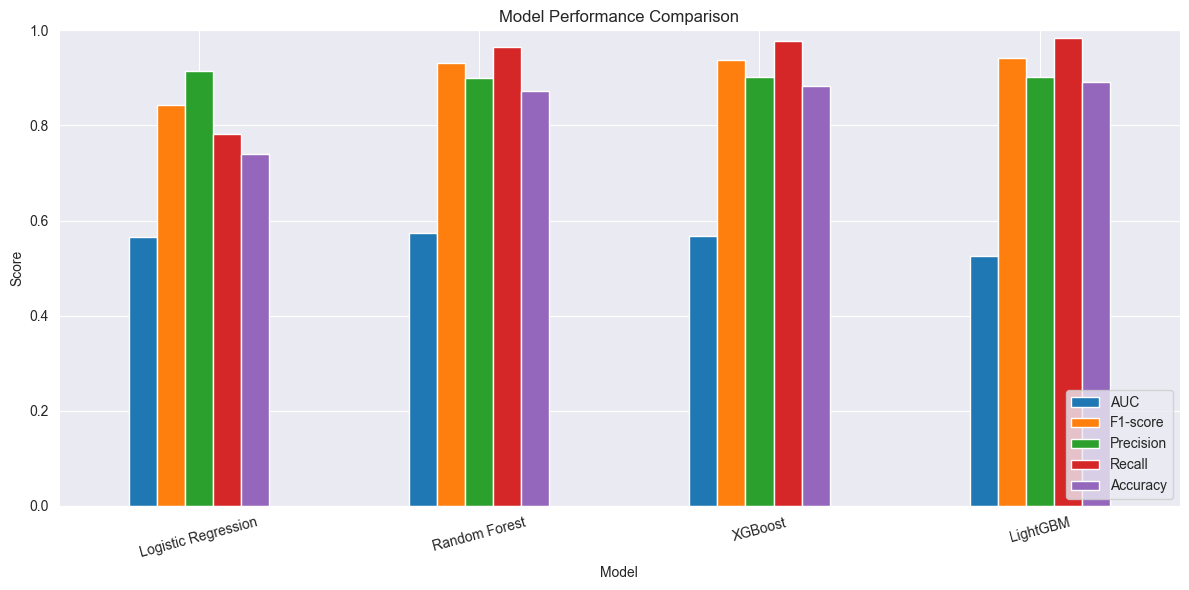

In [51]:
# 6.1 Model Performance Comparison

model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'AUC': [lr_auc, rf_auc, xgb_auc, lgbm_auc],
    'F1-score': [lr_f1, rf_f1, xgb_f1, lgbm_f1],
    'Precision': [lr_precision, rf_precision, xgb_precision, lgbm_precision],
    'Recall': [lr_recall, rf_recall, xgb_recall, lgbm_recall],
    'Accuracy': [lr_accuracy, rf_accuracy, xgb_accuracy, lgbm_accuracy]
})

display(model_comparison.sort_values('AUC', ascending=False))

# Bar chart comparison
plot_df = model_comparison.set_index('Model')

ax = plot_df.plot(
    kind='bar',
    figsize=(12, 6),
    rot=15
)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Model Performance Comparison Analysis

The model comparison shows a clear pattern. Tree-based models outperform Logistic Regression on **accuracy**, **F1-score**, and **recall**, which suggests that churn in this dataset is not fully captured by simple linear relationships. Among them, **LightGBM** achieves the highest F1-score, recall, and accuracy, while **Random Forest** delivers the highest AUC.

However, the comparison also reveals an important limitation: **all AUC values remain low**, with the best model only reaching about **0.57**. This means that although the models are good at predicting the dominant churn class, their overall ranking and separation ability is still weak. In other words, better headline metrics do not necessarily mean better balanced discrimination.

This is a key reflection point for the project. At the current stage, model differences are real, but they are smaller than the broader structural problem created by the dataset itself: **extreme class imbalance** and a very small active-user group. Therefore, the next evaluation step should focus on **ROC curves, Precision-Recall curves, and confusion matrices**, rather than relying only on summary scores.

### 6.2 ROC Curve Comparison

This section compares the ROC curves of all trained models. ROC analysis is useful because it focuses on the model’s ability to rank churned and active users across different thresholds, rather than only at one fixed decision cutoff.

In this project, ROC comparison is especially important because the earlier results already suggest that high accuracy and F1-score may hide weak overall class separation.

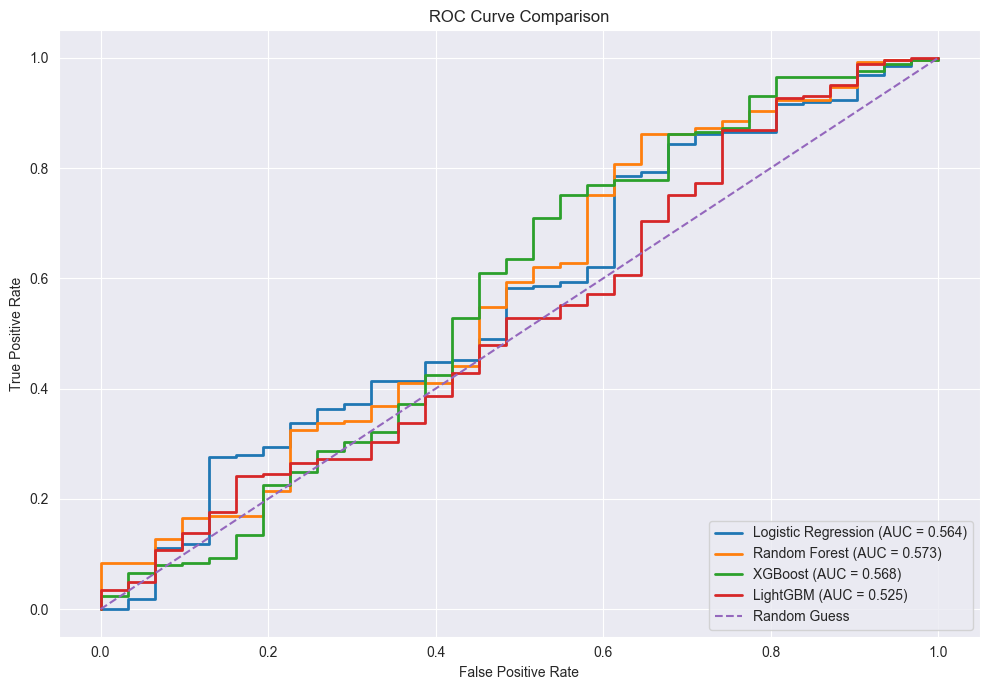

In [52]:
# 6.2 ROC Curve Comparison

from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 7))

model_probas = {
    'Logistic Regression': y_proba_lr,
    'Random Forest': y_proba_rf,
    'XGBoost': y_proba_xgb,
    'LightGBM': y_proba_lgbm
}

for model_name, y_proba in model_probas.items():
    fpr, tpr, _ = roc_curve(y_test_model, y_proba)
    auc_score = roc_auc_score(y_test_model, y_proba)
    plt.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1.5, label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### ROC Curve Comparison Analysis

The ROC comparison confirms that the four models have **very similar overall ranking ability**. Although Random Forest shows the highest AUC, the difference from Logistic Regression and XGBoost is small, and all curves remain close to the **random-guess line**. This means that none of the models achieves strong global separation between churned and active users.

This result is important because it challenges the earlier headline metrics. Even though some models had high accuracy, recall, and F1-score, the ROC curves show that their ability to rank users meaningfully is still limited. In other words, the models are better at fitting the dominant churn class than at producing a strong general decision boundary.

This is a useful reflection point for the project. The main bottleneck now appears to be less about choosing a stronger classifier and more about the **difficulty of the target structure itself**. Therefore, the next comparison should use **Precision-Recall curves**, which are often more informative in highly imbalanced classification settings.

### 6.3 Precision-Recall Curve Comparison

This section compares the Precision-Recall curves of all trained models. In a highly imbalanced churn setting, PR curves are often more informative than ROC curves because they focus more directly on the trade-off between **precision** and **recall** for the positive churn class.

This is important in the current project because the dataset contains many more churned users than active users. A useful model should therefore be judged not only by ranking ability, but also by whether it can maintain reasonable precision while capturing a large share of churned cases.

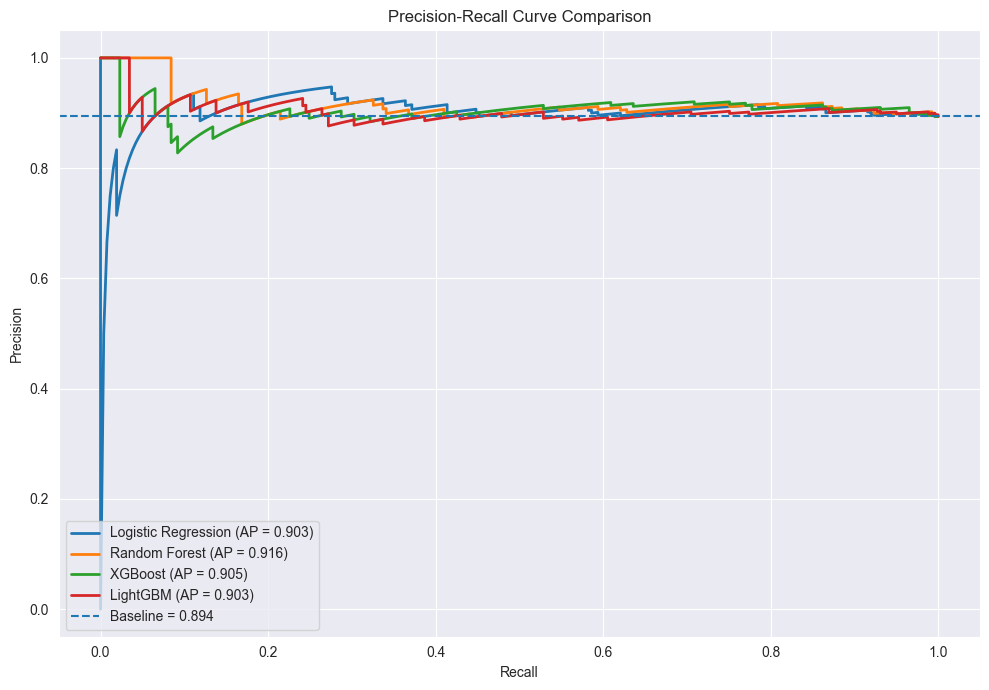

In [53]:
# 6.3 Precision-Recall Curve Comparison

from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))

for model_name, y_proba in model_probas.items():
    precision, recall, _ = precision_recall_curve(y_test_model, y_proba)
    ap_score = average_precision_score(y_test_model, y_proba)
    plt.plot(recall, precision, linewidth=2, label=f'{model_name} (AP = {ap_score:.3f})')

baseline = y_test_model.mean()
plt.axhline(y=baseline, linestyle='--', linewidth=1.5, label=f'Baseline = {baseline:.3f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

### Precision-Recall Curve Comparison Analysis

The Precision-Recall curves show a different picture from the ROC results. All four models remain **above the baseline**, and their **Average Precision** scores are relatively close, with **Random Forest** performing slightly best. This suggests that the models still have some value when the task is viewed mainly as identifying the dominant churn class.

However, the curves also show that the performance gain is **modest rather than dramatic**. Since the baseline precision is already very high due to the large churn proportion in the test set, even strong-looking PR values should not be over-interpreted. In this context, high precision is partly easier to achieve because the positive class is the majority.

This is an important reflection point. The PR curves confirm that the models are reasonably effective at detecting churned users, but they still do not solve the deeper issue of **weak separation from the small active group**. Therefore, the next step should move from curve-level comparison to a more concrete diagnostic view through the **confusion matrix of the selected best model**.

### 6.4 Confusion Matrix of the Best Model

This section examines the confusion matrix of the selected best model. Unlike AUC or PR curves, the confusion matrix shows the model’s behaviour at the **actual classification threshold**, which makes it more directly interpretable from a business perspective.

This is especially useful in churn prediction because the practical value of a model depends not only on overall ranking quality, but also on how many **active users are incorrectly flagged** and how many **true churned users are missed**.

Selected best model: Random Forest

Confusion Matrix:
[[  3  28]
 [  9 252]]

Detailed counts:
True Negatives  (correctly predicted Active)   : 3
False Positives (Active predicted as Churned)  : 28
False Negatives (Churned predicted as Active)  : 9
True Positives  (correctly predicted Churned)  : 252


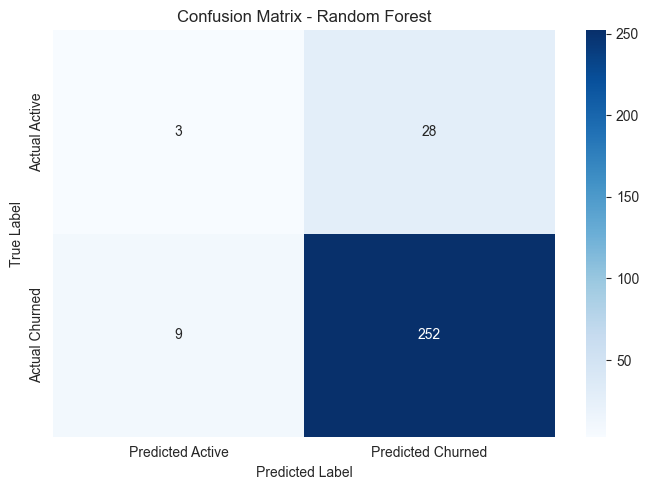

In [54]:
# 6.4 Confusion Matrix of the Best Model

best_model_name = 'Random Forest'
best_model = rf_model
best_pred = y_pred_rf
best_proba = y_proba_rf

print(f"Selected best model: {best_model_name}")

cm_best = confusion_matrix(y_test_model, best_pred)
tn, fp, fn, tp = cm_best.ravel()

print("\nConfusion Matrix:")
print(cm_best)

print("\nDetailed counts:")
print(f"True Negatives  (correctly predicted Active)   : {tn}")
print(f"False Positives (Active predicted as Churned)  : {fp}")
print(f"False Negatives (Churned predicted as Active)  : {fn}")
print(f"True Positives  (correctly predicted Churned)  : {tp}")

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_best,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Active', 'Predicted Churned'],
    yticklabels=['Actual Active', 'Actual Churned']
)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### Confusion Matrix Analysis

The confusion matrix shows that the selected Random Forest model is **very strong at identifying churned users** but **very weak at recognising active users**. It correctly classifies **252 churned users** and misses only **9**, which explains its high recall for the churn class. From a retention-monitoring perspective, this means the model is unlikely to overlook many users who are already at churn risk.

However, the opposite side is much weaker. The model correctly identifies only **3 active users**, while **28 active users are wrongly predicted as churned**. This means the model has a strong tendency to push users into the churn class, which is consistent with the earlier imbalance problem. In practice, such a model may support broad churn targeting, but it is still limited for **precise intervention**, because too many retained users would be flagged unnecessarily.

This is an important reflection point. The model is useful for detecting the dominant churn pattern, but it is not yet a well-balanced decision tool. Therefore, the next step should focus on **feature importance and model interpretability**, so that the project can move from prediction performance to understanding **why** churn is being predicted.

## 7. Model Interpretation and Feature Importance

After model selection, the next step is to examine **why** the model makes its churn predictions. This is important because a churn model is more valuable when it not only predicts risk, but also helps explain the underlying drivers behind that risk.

In this project, interpretation is especially necessary because the earlier results showed that predictive performance is uneven across classes. Feature importance can therefore help assess whether the model is relying on **meaningful business signals** or mainly on narrow label-adjacent patterns.

### 7.1 Feature Importance (Best Tree-Based Model)

This section uses the selected **Random Forest** model to measure feature importance. Tree-based importance is useful because it provides a first global view of which variables contribute most to the model’s decisions.

However, this measure should still be interpreted carefully. A high-importance feature is not automatically causal, and importance scores may sometimes reflect **feature redundancy** or closeness to the target logic rather than a clean business driver.

Top 20 important features:


,Feature,Importance
17,total_category_purchases,0.062836
4,recency_ratio,0.053323
7,days_since_last_order,0.052691
9,rating_std,0.049656
52,customer_state_RJ,0.044737
12,avg_delivery_days,0.042098
5,is_recent_active,0.038592
8,avg_rating,0.037628
58,customer_state_SP,0.036663
63,dominant_category_automotivo,0.029822


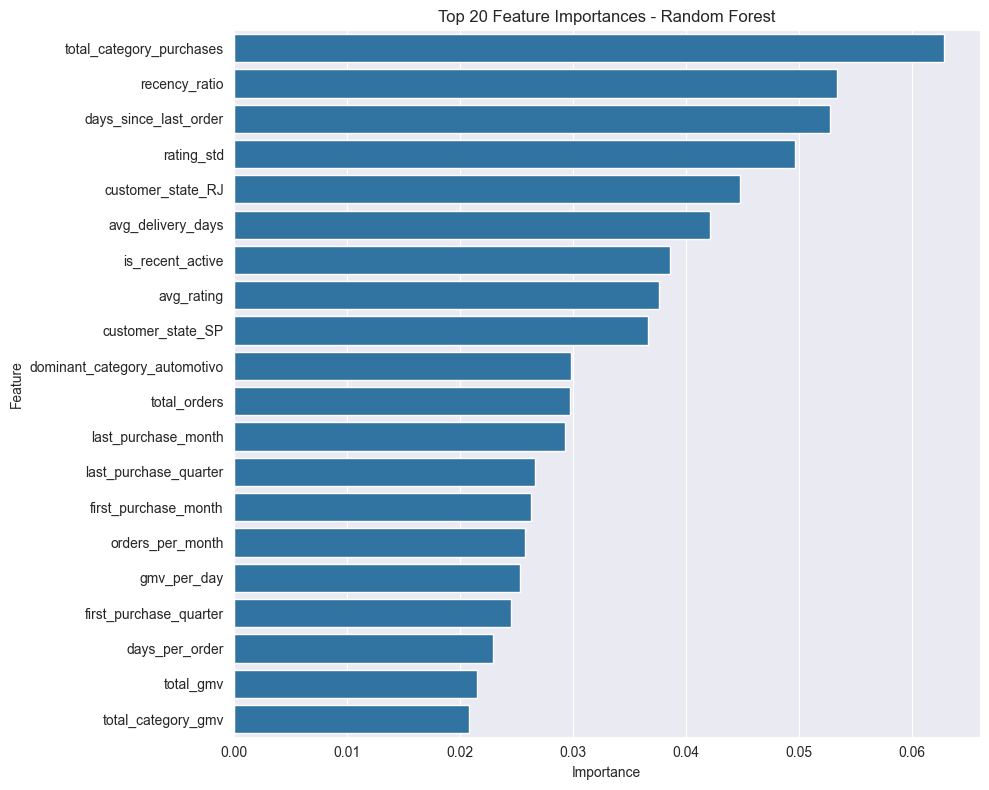

In [55]:
# 7.1 Feature Importance (Random Forest)

# Get processed feature names after preprocessing
processed_feature_names = preprocessor.get_feature_names_out()
processed_feature_names = [
    name.replace('num__', '').replace('cat__', '')
    for name in processed_feature_names
]

# Build feature importance table
feature_importance = pd.DataFrame({
    'Feature': processed_feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

top_20_features = feature_importance.head(20).copy()

print("Top 20 important features:")
display(top_20_features)

# Plot top 20
plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_20_features,
    y='Feature',
    x='Importance'
)
plt.title('Top 20 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Feature Importance Analysis

The Random Forest importance ranking suggests that churn prediction in this project is driven by a **combination of behavioural, service, category, and geographic signals**, rather than by a single dominant variable. The most important features include ``total_category_purchases``, ``recency_ratio``, and ``days_since_last_order``, which indicates that **purchase activity rhythm** remains central to the model’s decisions.

At the same time, the ranking also shows meaningful contributions from ``rating_std``, ``avg_delivery_days``, ``avg_rating``, and state-related features such as ``customer_state_RJ`` and ``customer_state_SP``. This suggests that churn is not explained only by inactivity, but also by **service experience** and **regional context**. That is a useful business insight, because it implies that retention risk may emerge from several interacting dimensions.

However, these results should still be interpreted critically. Some high-importance features, especially ``recency_ratio`` and ``days_since_last_order``, are relatively close to the churn definition itself, so part of their importance may reflect **label proximity** rather than deeper causal influence. Therefore, the next interpretation step should go beyond ranking and examine **directional effects**, so that the project can better distinguish operational insight from purely predictive convenience.

### 7.2 SHAP Global Interpretation

This section uses **SHAP values** to provide a more detailed global explanation of the selected model. Unlike standard feature importance, SHAP helps show not only which features matter, but also how they push predictions toward **higher** or **lower** churn risk.

This is important because a feature can be influential without having a simple one-directional effect. SHAP therefore provides a more interpretable bridge between model output and business understanding.

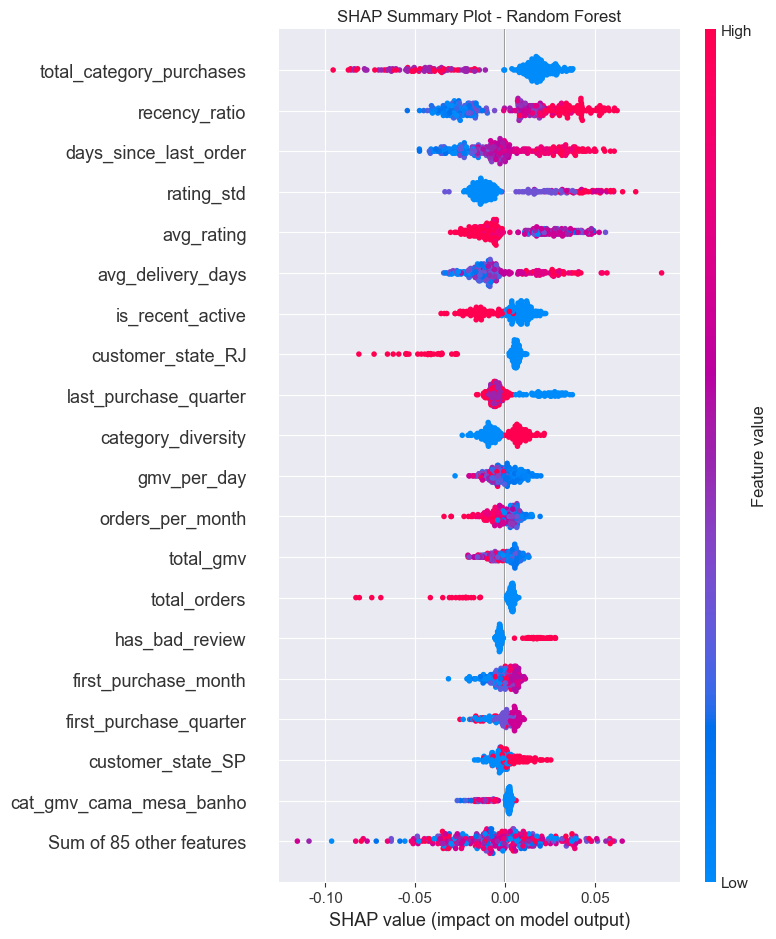

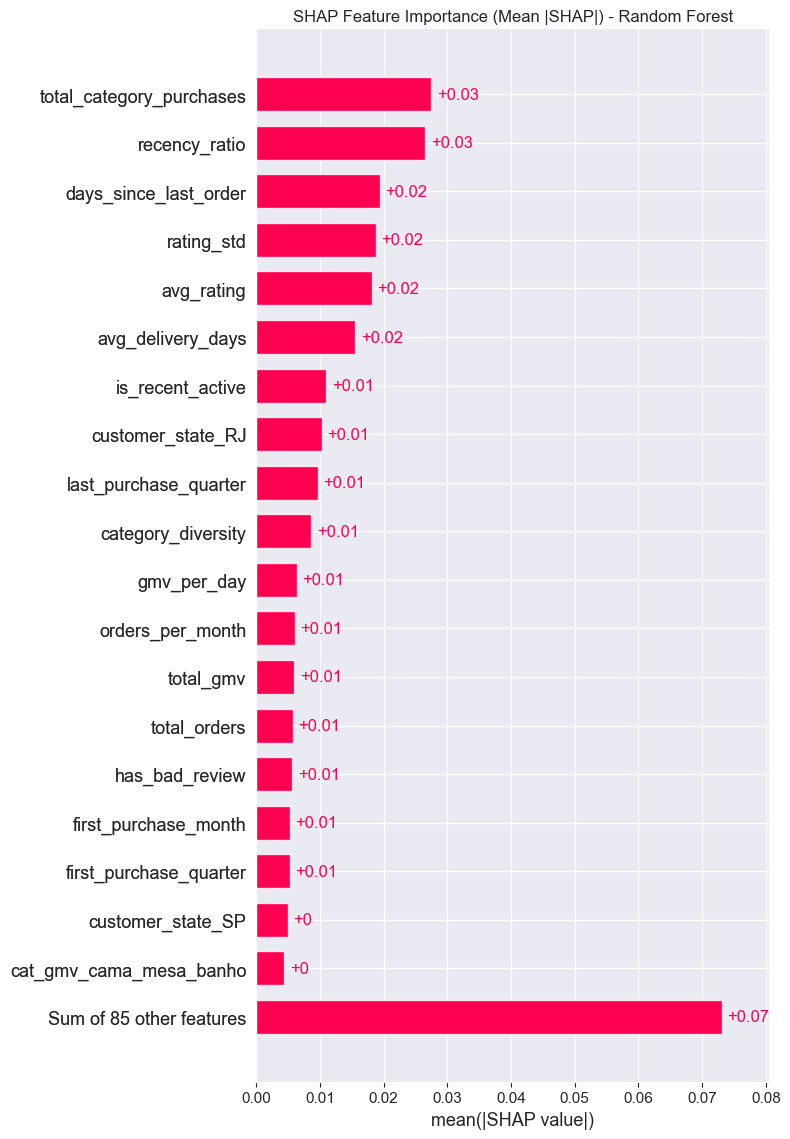

In [57]:
# 7.2 SHAP Global Interpretation - fixed version

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build DataFrame with processed feature names
X_train_shap_df = pd.DataFrame(X_train_processed, columns=processed_feature_names)
X_test_shap_df = pd.DataFrame(X_test_processed, columns=processed_feature_names)

# Use SHAP explainer
explainer = shap.Explainer(rf_model, X_train_shap_df)
shap_exp = explainer(X_test_shap_df)

# Handle binary-class output safely
if len(shap_exp.values.shape) == 3:
    # shape: (n_samples, n_features, n_classes)
    shap_exp_churn = shap.Explanation(
        values=shap_exp.values[:, :, 1],
        base_values=shap_exp.base_values[:, 1],
        data=X_test_shap_df.values,
        feature_names=processed_feature_names
    )
else:
    shap_exp_churn = shap_exp

# Beeswarm summary plot
plt.figure()
shap.plots.beeswarm(shap_exp_churn, max_display=20, show=False)
plt.title("SHAP Summary Plot - Random Forest")
plt.tight_layout()
plt.show()

# Bar plot
plt.figure()
shap.plots.bar(shap_exp_churn, max_display=20, show=False)
plt.title("SHAP Feature Importance (Mean |SHAP|) - Random Forest")
plt.tight_layout()
plt.show()

### SHAP Global Interpretation Analysis

The SHAP results confirm that the model relies mainly on a small set of features related to **purchase activity**, **recency**, and **service experience**. The most influential variables include ``total_category_purchases``, ``recency_ratio``, ``days_since_last_order``, ``rating_std``, ``avg_rating``, and ``avg_delivery_days``. This is broadly consistent with the earlier feature-importance ranking and suggests that churn is shaped by a mixture of **behavioural inactivity** and **post-purchase experience**.

The beeswarm plot also adds directional insight. Higher ``recency_ratio`` and higher ``days_since_last_order`` tend to push predictions toward **higher churn risk**, while stronger purchase activity such as higher ``total_category_purchases`` tends to push predictions in the opposite direction. Service-related features also matter: more unstable ratings and longer delivery times appear to contribute to higher churn risk. This makes the model more interpretable from a business perspective, because the main signals are not purely abstract statistical patterns.

However, the interpretation should still be treated critically. Some of the strongest SHAP drivers, especially ``recency_ratio`` and ``days_since_last_order``, remain quite close to the churn definition itself. This means the model is learning useful signals, but part of its explanation may still reflect **label-adjacent behaviour** rather than deeper causal drivers. The next step should therefore move from global importance to **local explanation**, so that individual churn predictions can be examined in more concrete detail.
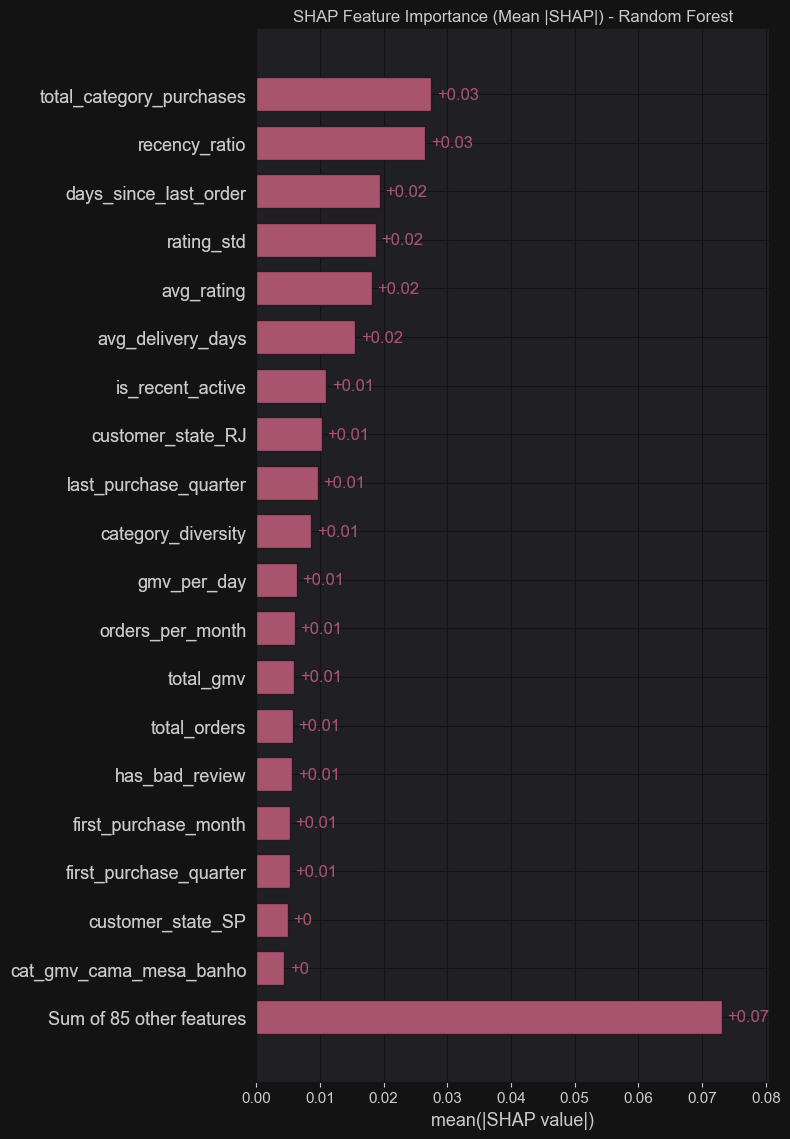

### 7.3 SHAP Local Interpretation

This section examines SHAP explanations at the **individual prediction level**. Global importance shows which features matter overall, but local explanation is useful for understanding **why one specific customer** is predicted as churned or retained.

This is especially valuable in churn analysis because intervention decisions are often made customer by customer. A local view can therefore connect model output more directly to practical retention action.

Selected churned test case index: 0
Selected active test case index : 13


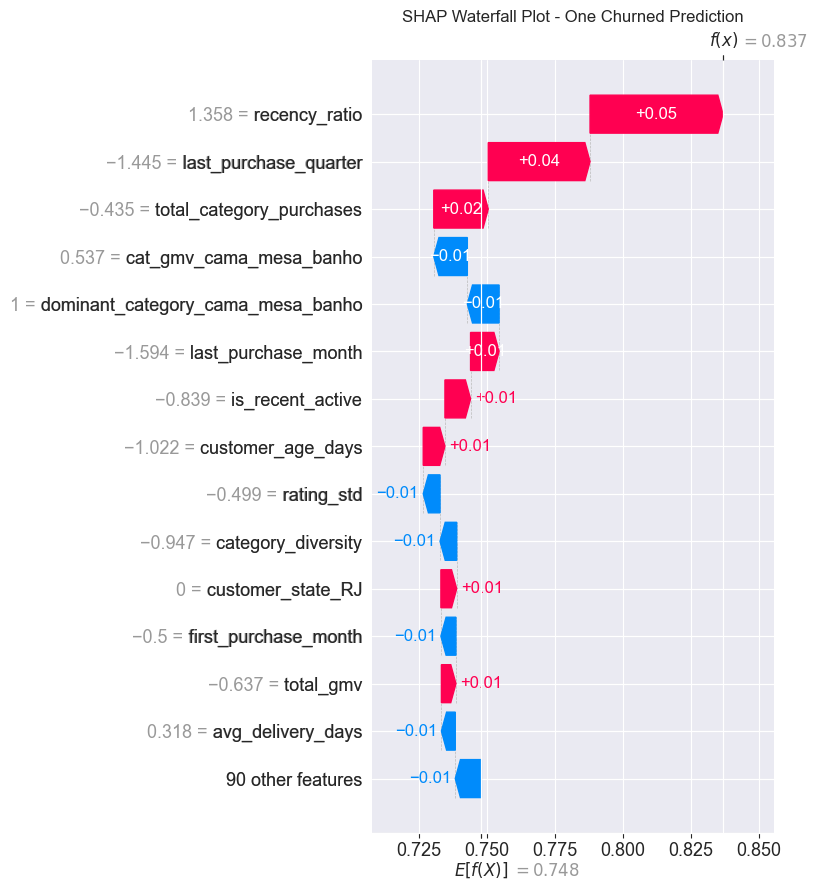

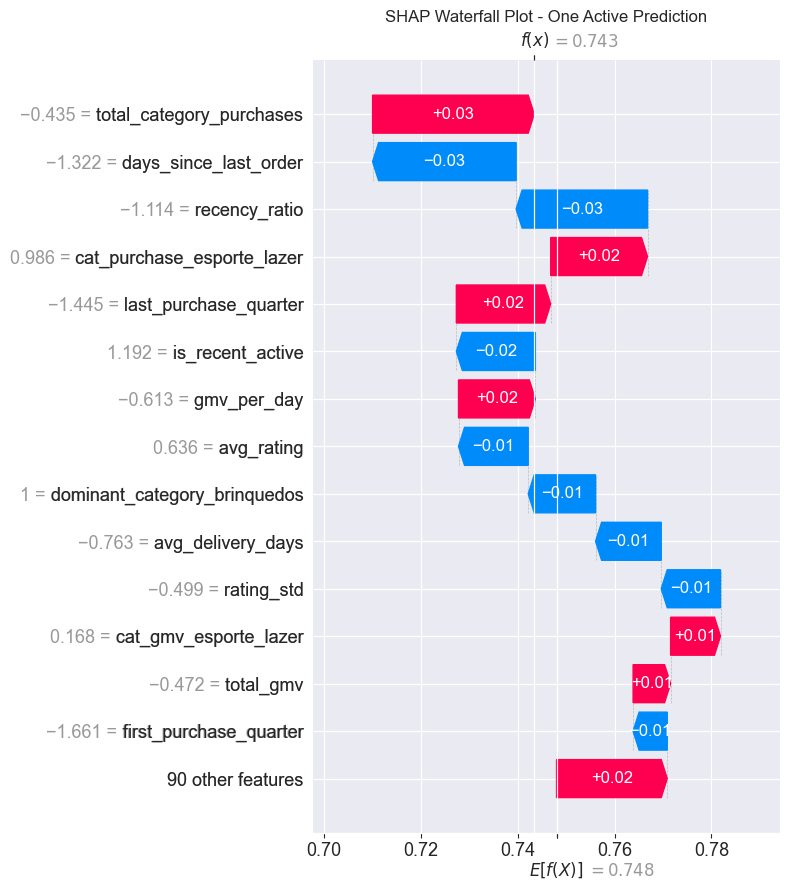

In [58]:
# 7.3 SHAP Local Interpretation

# Find one churned case and one active case from the test set
churn_idx = np.where(y_test_model.values == 1)[0][0]
active_idx = np.where(y_test_model.values == 0)[0][0]

print("Selected churned test case index:", churn_idx)
print("Selected active test case index :", active_idx)

# Waterfall plot for one churned user
plt.figure()
shap.plots.waterfall(shap_exp_churn[churn_idx], max_display=15, show=False)
plt.title("SHAP Waterfall Plot - One Churned Prediction")
plt.tight_layout()
plt.show()

# Waterfall plot for one active user
plt.figure()
shap.plots.waterfall(shap_exp_churn[active_idx], max_display=15, show=False)
plt.title("SHAP Waterfall Plot - One Active Prediction")
plt.tight_layout()
plt.show()

### SHAP Local Interpretation Analysis

The local SHAP explanations show that individual churn predictions are driven by a **combination of reinforcing and offsetting factors**, rather than by one feature alone. In the churned example, higher ``recency_ratio`` and later purchase-timing variables push the prediction further toward churn, which is consistent with the global interpretation that inactivity-related signals remain central.

The active example is also informative. Lower ``days_since_last_order`` and lower ``recency_ratio`` help reduce churn risk, while some category and value-related signals push in the opposite direction. This suggests that even when the final prediction stays closer to retention, the model is still balancing several competing influences rather than relying on a single decisive feature.

This is a useful reflection point. Local SHAP makes the model more interpretable at the customer level, but it also confirms that many important drivers are still closely related to **purchase timing and recency structure**. Therefore, the model can support case-level explanation, yet its business interpretation should still distinguish between **true operational drivers** and features that are simply close to the churn label itself.

### 7.4 SHAP Dependence Plot

This section uses SHAP dependence plots to examine how specific features influence churn prediction across many observations. Compared with global ranking and single-case explanation, dependence plots are useful for showing whether a feature has a **consistent directional effect** or a more complex non-linear relationship.

This is especially relevant in churn modelling because some features may appear important overall, but their actual impact may change across different value ranges or user contexts.

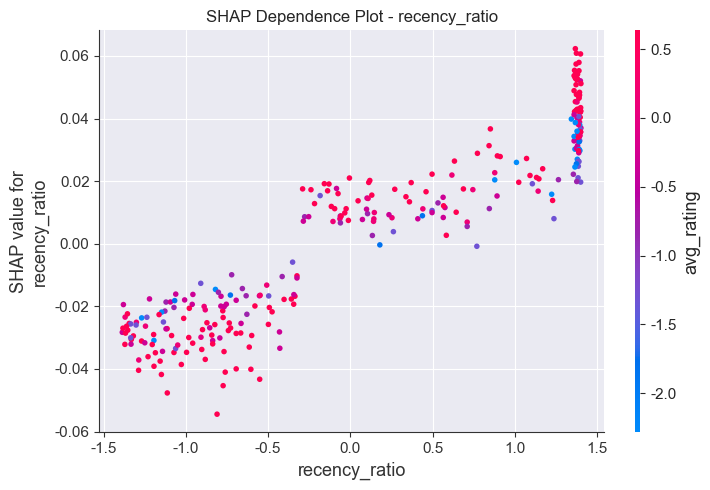

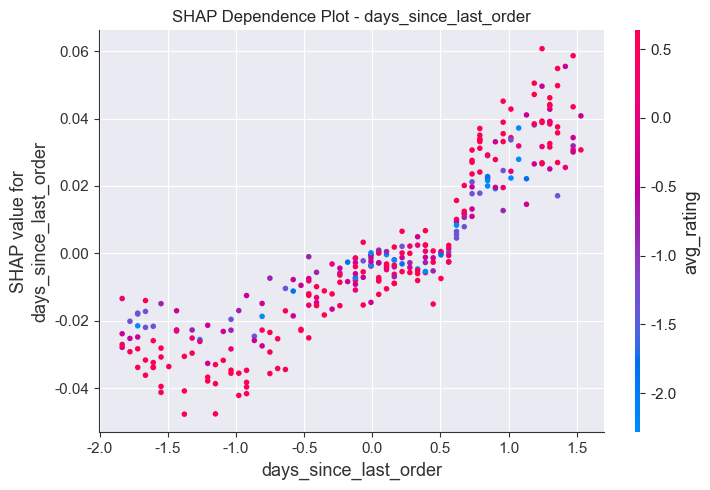

In [59]:
# 7.4 SHAP Dependence Plot

# recency_ratio
shap.dependence_plot(
    'recency_ratio',
    shap_exp_churn.values,
    X_test_shap_df,
    feature_names=processed_feature_names,
    interaction_index='auto',
    show=False
)
plt.title("SHAP Dependence Plot - recency_ratio")
plt.tight_layout()
plt.show()

# days_since_last_order
shap.dependence_plot(
    'days_since_last_order',
    shap_exp_churn.values,
    X_test_shap_df,
    feature_names=processed_feature_names,
    interaction_index='auto',
    show=False
)
plt.title("SHAP Dependence Plot - days_since_last_order")
plt.tight_layout()
plt.show()

### SHAP Dependence Plot Analysis

Both dependence plots show a clear pattern: as ``recency_ratio`` and ``days_since_last_order`` increase, their SHAP values also rise, which means the model assigns **higher churn risk** to users with longer inactivity. This suggests that the relationship is not random, but broadly **monotonic and stable**.

At the same time, this result should be read carefully. These variables are highly useful, but they are also close to the churn definition itself. So the plots confirm strong predictive signal, while also reminding us that part of the model’s explanation may come from **label-adjacent timing features** rather than deeper behavioural drivers.

## 8. Churn Risk Segmentation

After model interpretation, the next step is to convert prediction results into **risk scores** that can support business action. The purpose is not only to identify likely churned cases, but also to organise customers into more practical intervention groups.

In this project, risk segmentation is important because prediction alone is not the final goal. The model becomes more useful when churn probabilities can be translated into **prioritised retention decisions**.

### 8.1 Churn Probability Distribution

This section applies the selected best model to the full modelling table and generates a churn probability for each observation. Examining the probability distribution is useful because it shows whether the model produces **meaningful spread** in risk, rather than assigning almost all cases the same score.

A good scoring model should create enough variation to support later segmentation into different risk levels.

Churn probability summary:


count    1224.000000
mean        0.747053
std         0.144854
min         0.105135
25%         0.695161
50%         0.783394
75%         0.847244
max         0.940667
Name: churn_probability, dtype: float64

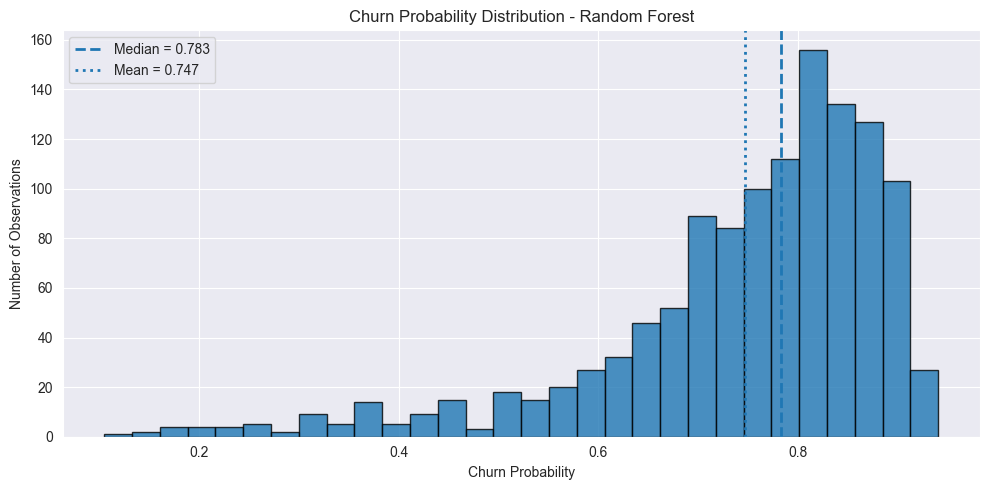

In [62]:
# 8.1 Churn Probability Distribution

# Use the selected best model: Random Forest
feature_input_cols = numeric_features_final + categorical_features

X_all = df_fe[feature_input_cols].copy()
X_all_processed = preprocessor.transform(X_all)

df_scored = df_fe.copy()
df_scored['churn_probability'] = rf_model.predict_proba(X_all_processed)[:, 1]

print("Churn probability summary:")
display(df_scored['churn_probability'].describe())

plt.figure(figsize=(10, 5))
plt.hist(df_scored['churn_probability'], bins=30, edgecolor='black', alpha=0.8)
plt.axvline(df_scored['churn_probability'].median(), linestyle='--', linewidth=2,
            label=f"Median = {df_scored['churn_probability'].median():.3f}")
plt.axvline(df_scored['churn_probability'].mean(), linestyle=':', linewidth=2,
            label=f"Mean = {df_scored['churn_probability'].mean():.3f}")
plt.title('Churn Probability Distribution - Random Forest')
plt.xlabel('Churn Probability')
plt.ylabel('Number of Observations')
plt.legend()
plt.tight_layout()
plt.show()

### Churn Probability Distribution Analysis

The predicted churn probabilities show a **clear concentration at the higher end**, with a mean of **0.747** and a median of **0.783**. This is consistent with the earlier finding that the dataset is dominated by churned observations, so the model naturally assigns relatively high risk scores to a large share of cases.

At the same time, the scores are **not completely collapsed into one narrow range**. The distribution still spans from about **0.11** to **0.94**, which means the model produces enough variation to support later risk segmentation. However, this should still be interpreted carefully: a broad high-risk pattern may reflect real churn prevalence, but it may also show that the model remains more confident about the dominant churn class than about identifying clearly retained users.

### 8.2 Risk Level Definition

This section converts churn probabilities into **risk segments** that can be used for business action. Instead of treating all predicted users in the same way, segmentation makes it possible to prioritise intervention by different levels of estimated churn risk.

Because the score distribution is already concentrated toward higher churn probability, the segmentation rule should create groups that are still interpretable and operationally useful.

Low-risk cutoff  : 0.7260
High-risk cutoff : 0.8268
Risk segment summary:


,risk_level,observations,avg_probability,actual_churn_rate,total_gmv
0,Low Risk,404,0.586892,0.787129,153115.74
1,Medium Risk,416,0.782416,0.968750,123673.18
2,High Risk,404,0.870802,0.982673,106498.19


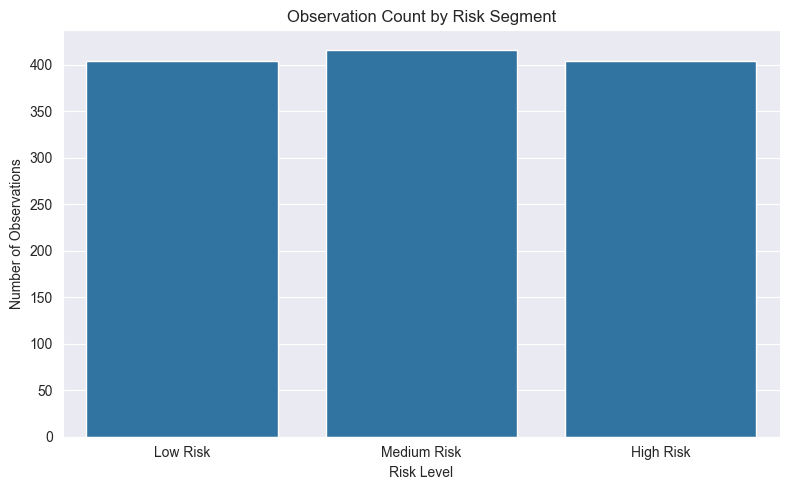

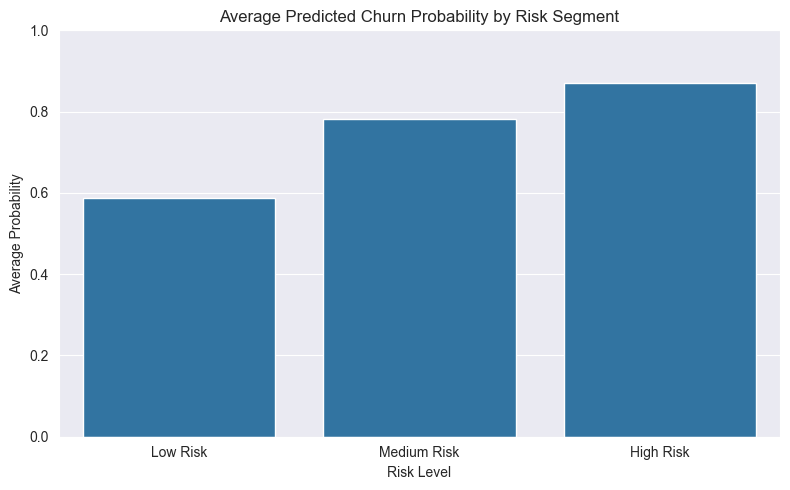

In [64]:
# 8.2 Risk Level Definition

df_scored = df_scored.copy()

# Quantile-based segmentation
low_cut = df_scored['churn_probability'].quantile(0.33)
high_cut = df_scored['churn_probability'].quantile(0.67)

print(f"Low-risk cutoff  : {low_cut:.4f}")
print(f"High-risk cutoff : {high_cut:.4f}")

df_scored['risk_level'] = pd.cut(
    df_scored['churn_probability'],
    bins=[-np.inf, low_cut, high_cut, np.inf],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

risk_summary = df_scored.groupby('risk_level').agg(
    observations=('unique_user_id', 'count'),
    avg_probability=('churn_probability', 'mean'),
    actual_churn_rate=('target', 'mean'),
    total_gmv=('total_gmv', 'sum')
).reset_index()

print("Risk segment summary:")
display(risk_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=risk_summary, x='risk_level', y='observations')
plt.title('Observation Count by Risk Segment')
plt.xlabel('Risk Level')
plt.ylabel('Number of Observations')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=risk_summary, x='risk_level', y='avg_probability')
plt.title('Average Predicted Churn Probability by Risk Segment')
plt.xlabel('Risk Level')
plt.ylabel('Average Probability')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Risk Level Definition Analysis

The risk segmentation produces a **clear probability gradient** from Low Risk to High Risk, and the actual churn rate also rises across the three groups. This suggests that the model scores are not random: higher predicted risk is broadly associated with higher observed churn.

However, the result also shows an important limitation. Even the **Low Risk** group still has a high actual churn rate (**78.7%**), which means the segmentation improves prioritisation but does **not create a truly low-churn population**. In other words, the model can rank risk levels, but the whole dataset remains structurally churn-heavy. This is useful for targeting, but it also means later business action should focus on **relative priority**, not on assuming that low-risk users are actually safe.
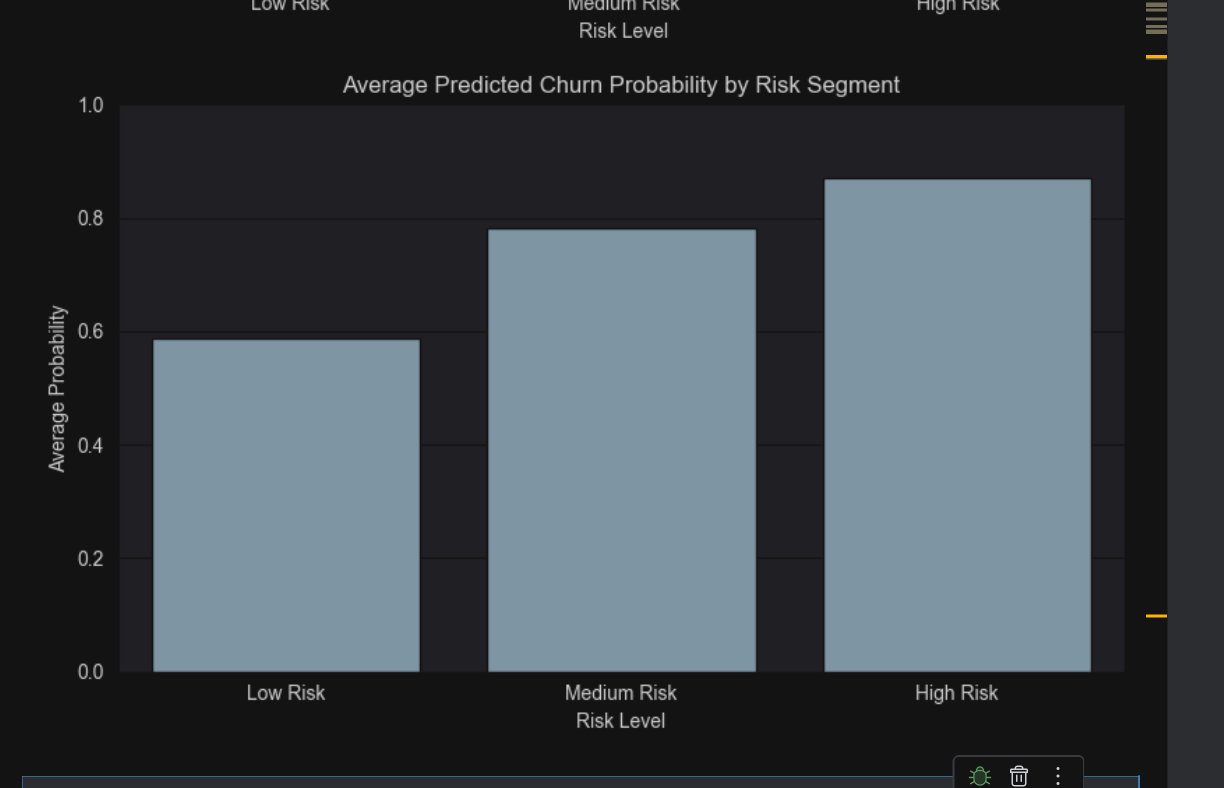
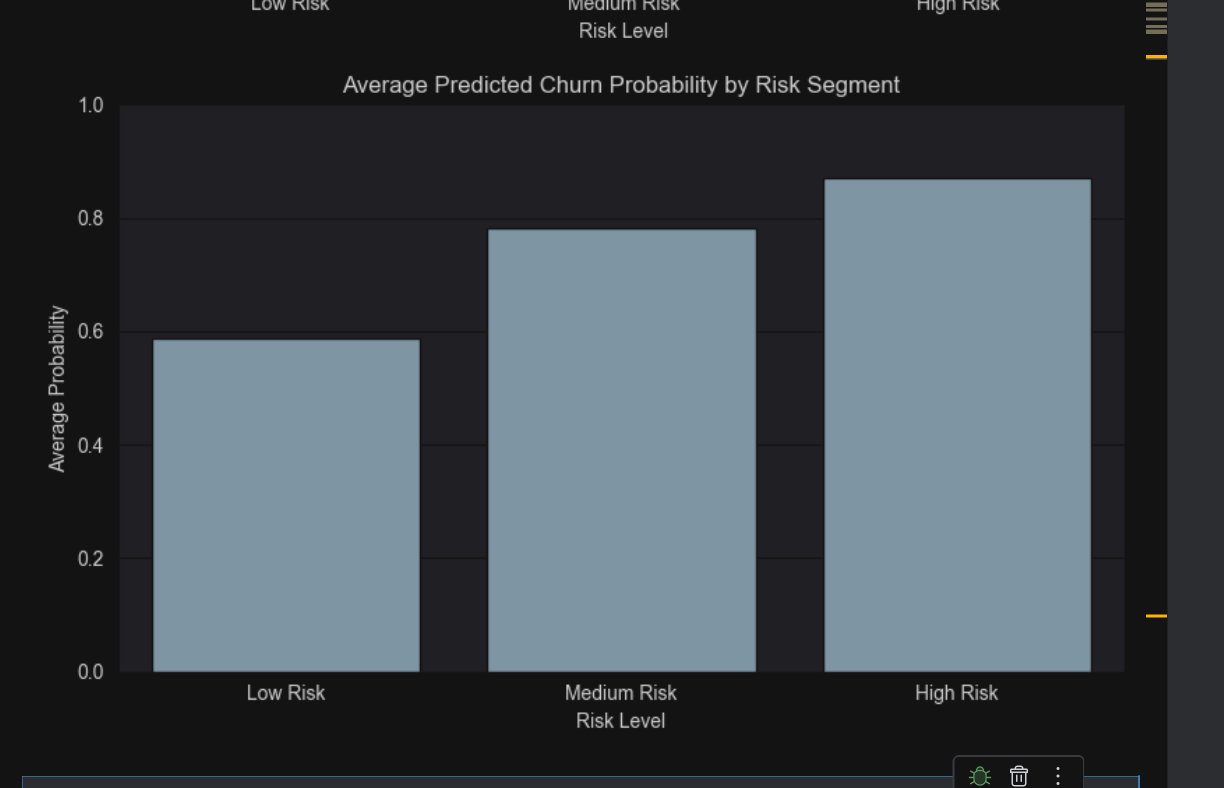
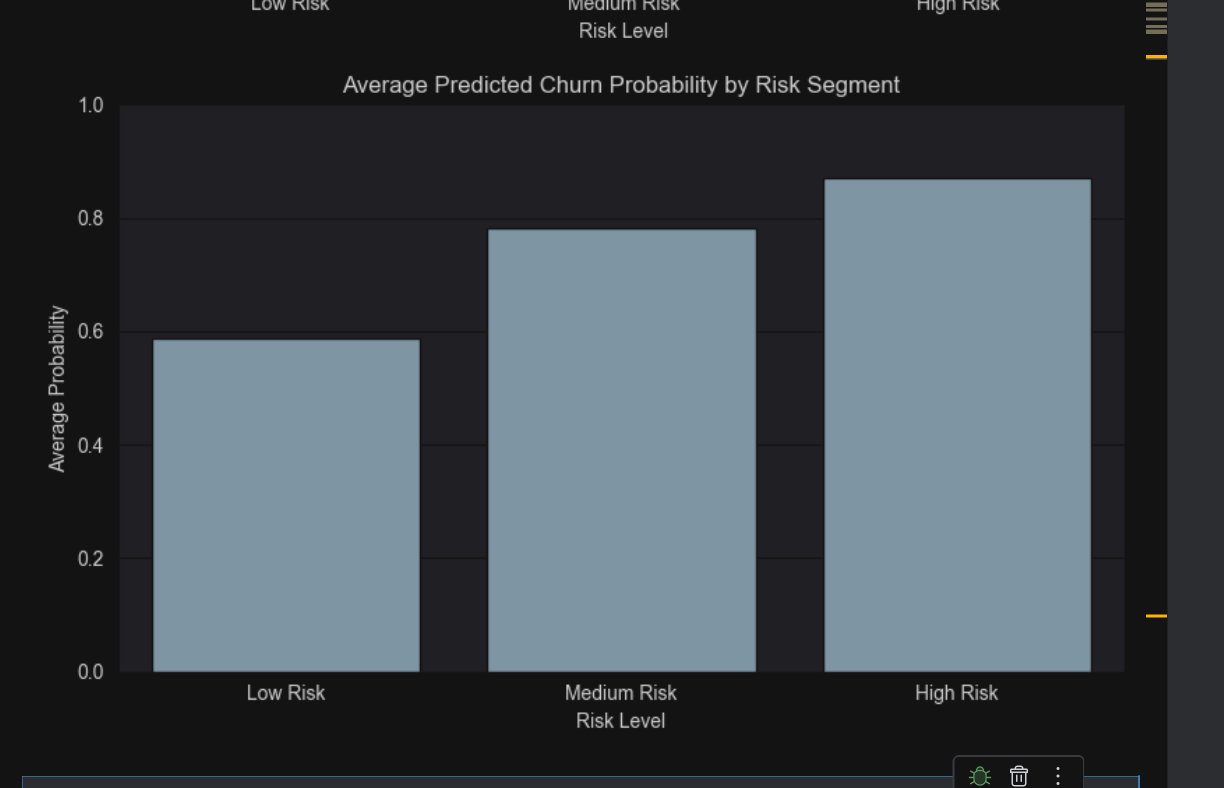

### 8.3 High-Value High-Risk User Identification

This section identifies the users who are both **high value** and **high risk**, since they are usually the most important targets for retention action. In business terms, these are the users whose potential churn may cause a relatively large revenue loss.

Because the modelling table is snapshot-based, this step uses the **latest available snapshot per user** before ranking priority users. This makes the retention list more practical and avoids repeated records for the same customer.

Latest-user scoring table shape: (830, 69)
Unique users: 830
High-value threshold (total_gmv): 363.43
High-value high-risk users: 70
Share of latest users: 8.43%
GMV share: 17.16%
Top 20 high-value high-risk users:


,unique_user_id,snapshot_id,churn_probability,risk_level,total_gmv,total_orders,days_since_last_order,avg_rating,avg_delivery_days,customer_state
609,59d66d72939bc9497e19d89c61a96d5f,5,0.836174,High Risk,3559.99,2,54,5.0000,16.5000,SP
504,ca6d9bc2e717c2a0aa19d77a3bfa5398,4,0.855225,High Risk,1237.39,2,59,1.0000,32.0000,RJ
975,0aadc1d26d1c8b88a52c39a533ccea93,7,0.833837,High Risk,1218.70,2,4,1.0000,22.0000,BA
824,6bb535b0906b43e0041916897667aeed,6,0.840843,High Risk,1195.23,3,46,3.6667,14.5000,SC
890,ae53a87a257f8e54795af6ff434e443b,6,0.900962,High Risk,1019.41,2,49,4.0000,19.5000,BA
872,98758d88bf4b8eef1372ddee45d63178,6,0.845919,High Risk,997.96,2,46,3.0000,38.0000,AL
1013,31bfa97f1ea0663a50ebc5c811ebdf4d,7,0.830957,High Risk,937.36,2,30,2.5000,16.0000,SP
783,37545efd489b0b7c9aa20690f344271d,6,0.866733,High Risk,897.68,2,45,5.0000,18.0000,RO
463,8b160faff469868625c7c82cbd310636,4,0.875057,High Risk,871.53,2,52,1.0000,8.0000,SP
979,0cc2ee1112a11a1094eff52fa2e87150,7,0.840222,High Risk,839.62,3,60,5.0000,16.5000,PI


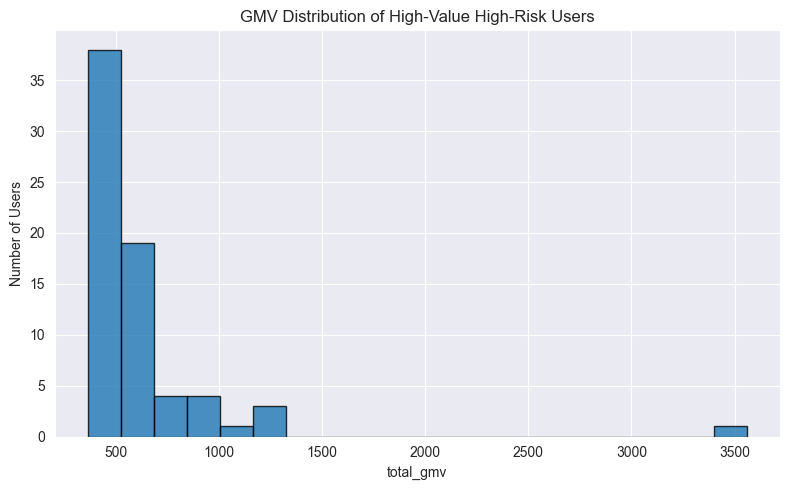

In [65]:
# 8.3 High-Value High-Risk User Identification

# Keep only the latest snapshot for each user
df_latest = (
    df_scored
    .sort_values(['unique_user_id', 'snapshot_id'])
    .groupby('unique_user_id', as_index=False)
    .tail(1)
    .copy()
)

print("Latest-user scoring table shape:", df_latest.shape)
print("Unique users:", df_latest['unique_user_id'].nunique())

# Define high-value users by top 25% GMV
high_value_threshold = df_latest['total_gmv'].quantile(0.75)
df_latest['is_high_value'] = (df_latest['total_gmv'] >= high_value_threshold).astype(int)

# High-value and high-risk users
hvhr_users = df_latest[
    (df_latest['is_high_value'] == 1) &
    (df_latest['risk_level'] == 'High Risk')
].copy()

print(f"High-value threshold (total_gmv): {high_value_threshold:.2f}")
print(f"High-value high-risk users: {len(hvhr_users)}")
print(f"Share of latest users: {len(hvhr_users) / len(df_latest):.2%}")
print(f"GMV share: {hvhr_users['total_gmv'].sum() / df_latest['total_gmv'].sum():.2%}")

top_20_hvhr = hvhr_users.sort_values('total_gmv', ascending=False)[[
    'unique_user_id', 'snapshot_id', 'churn_probability', 'risk_level',
    'total_gmv', 'total_orders', 'days_since_last_order',
    'avg_rating', 'avg_delivery_days', 'customer_state'
]].head(20)

print("Top 20 high-value high-risk users:")
display(top_20_hvhr)

# Optional simple visual
plt.figure(figsize=(8, 5))
plt.hist(hvhr_users['total_gmv'], bins=20, edgecolor='black', alpha=0.8)
plt.title('GMV Distribution of High-Value High-Risk Users')
plt.xlabel('total_gmv')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

### High-Value High-Risk User Analysis

Using the latest snapshot per user, the model identifies **70 high-value high-risk users**, representing **8.43%** of all users but **17.16%** of total GMV. This suggests that churn risk is not only a volume problem, but also a **revenue concentration problem**, since a relatively small group accounts for a disproportionately large share of value.

The GMV distribution is also clearly right-skewed, with a few very large users at the top. This is useful for business prioritisation because it means retention action should not treat all high-risk users equally. However, it should still be interpreted carefully: these users are high-priority targets, but the model’s earlier limitations mean that intervention lists should be viewed as **decision support**, not as perfect ground truth.

## 9. Retention Strategy Design

After risk segmentation, the final step is to translate model output into **practical retention actions**. The goal is not only to identify churn risk, but to connect that risk to different levels of business response.

This is important because a churn model creates value only when its predictions can support more targeted and cost-effective intervention.

### 9.1 Risk-Based Retention Strategy Framework

This section defines a simple retention strategy framework for **Low Risk**, **Medium Risk**, and **High Risk** users. The purpose is to match intervention intensity to estimated churn risk, instead of applying the same action to all users.

A good strategy framework should remain interpretable and operationally realistic, even before more detailed ROI assumptions are introduced.

In [66]:
# 9.1 Risk-Based Retention Strategy Framework

retention_strategy = pd.DataFrame({
    'Risk Level': ['Low Risk', 'Medium Risk', 'High Risk'],
    'Intervention Intensity': ['Low', 'Medium', 'High'],
    'Suggested Action': [
        'Routine engagement: email reminders, product recommendations',
        'Active retention: coupons, loyalty points, personalised offers',
        'Urgent retention: high-value coupon, service outreach, priority support'
    ],
    'Main Channel': [
        'Email / App push',
        'Email + App push + Coupon',
        'Email + App push + Direct support'
    ],
    'Business Objective': [
        'Maintain activity',
        'Prevent disengagement',
        'Recover likely churn'
    ]
})

print("Retention strategy framework:")
display(retention_strategy)

Retention strategy framework:


,Risk Level,Intervention Intensity,Suggested Action,Main Channel,Business Objective
0,Low Risk,Low,"Routine engagement: email reminders, product r...",Email / App push,Maintain activity
1,Medium Risk,Medium,"Active retention: coupons, loyalty points, per...",Email + App push + Coupon,Prevent disengagement
2,High Risk,High,"Urgent retention: high-value coupon, service o...",Email + App push + Direct support,Recover likely churn


### Retention Strategy Framework Analysis

The retention framework creates a clear link between **predicted risk level** and **intervention intensity**. This is useful because it turns the churn model from a scoring tool into a more actionable decision framework, where low-risk users are maintained, medium-risk users are stabilised, and high-risk users are prioritised for stronger recovery action.

At the same time, this framework should be treated as a **starting structure**, not a final optimisation rule. The strategy logic is reasonable, but its real business value still depends on later testing, cost control, and whether each channel-action combination actually improves retention in practice.

### 9.2 Personalised Retention Rules

This section adds a simple personalised strategy layer for the **high-risk** group. Instead of giving all high-risk users the same intervention, the rules link churn risk to a few interpretable drivers such as inactivity, low rating, delivery friction, and lower value level.

This makes the strategy more practical, while still keeping the logic transparent and easy to explain.

In [67]:
# 9.2 Personalised Retention Rules

df_latest = df_latest.copy()

def get_personalized_strategy(row):
    strategies = []

    if row.get('days_since_last_order', 0) >= df_latest['days_since_last_order'].quantile(0.75):
        strategies.append('Long inactivity -> send reactivation offer')

    if row.get('avg_rating', 5) < 4:
        strategies.append('Low satisfaction -> service follow-up and apology coupon')

    if row.get('avg_delivery_days', 0) >= df_latest['avg_delivery_days'].quantile(0.75):
        strategies.append('Delivery friction -> logistics reassurance / fast-shipping incentive')

    if row.get('total_gmv', 0) >= df_latest['total_gmv'].quantile(0.75):
        strategies.append('High value -> priority retention with stronger incentive')

    if not strategies:
        strategies.append('General retention campaign')

    return ' | '.join(strategies)

df_latest['personalized_strategy'] = df_latest.apply(get_personalized_strategy, axis=1)

high_risk_sample = df_latest[df_latest['risk_level'] == 'High Risk'][[
    'unique_user_id', 'churn_probability', 'total_gmv',
    'days_since_last_order', 'avg_rating', 'avg_delivery_days',
    'personalized_strategy'
]].head(20)

print("High-risk user strategy examples:")
display(high_risk_sample)

High-risk user strategy examples:


,unique_user_id,churn_probability,total_gmv,days_since_last_order,avg_rating,avg_delivery_days,personalized_strategy
966,02168ea18740a0fdaaa15f11bebba5db,0.923039,264.04,54,3.0,22.5000,Long inactivity -> send reactivation offer | L...
967,027803eb28cc01fbdf5da72b109fabee,0.851688,101.43,46,5.0,16.0000,Delivery friction -> logistics reassurance / f...
367,031ea691b99fc101dcad357d1a83573f,0.875036,73.04,55,4.0,7.5000,Long inactivity -> send reactivation offer
1,0396c443fdda5498c7e9ed5b34871c5a,0.836875,120.84,31,5.0,13.5000,General retention campaign
83,03dabd77cb0ed7a26fafe19e36b67742,0.891856,99.45,51,5.0,19.5000,Long inactivity -> send reactivation offer | D...
221,0451ef5a31cea3e14ce02d768d7c9943,0.880891,387.39,47,4.5,21.5000,Delivery friction -> logistics reassurance / f...
537,04d3c2795b83634312bf3f86f41f7901,0.933576,596.39,56,3.0,21.0000,Long inactivity -> send reactivation offer | L...
222,053f7850c3ffd9726cff61c7e42af797,0.911866,61.54,36,2.0,5.0000,Low satisfaction -> service follow-up and apol...
370,05e52c1f96f8b83dd66dcdce679ff58d,0.929459,239.16,41,4.0,17.0000,Delivery friction -> logistics reassurance / f...
539,0621c2a5979d3e887ae519620cbe2926,0.844061,514.49,54,1.0,9.0000,Long inactivity -> send reactivation offer | L...


### Personalised Retention Rule Analysis

The personalised rule layer makes the retention strategy more actionable by linking **high-risk users** to different likely drivers, such as inactivity, low satisfaction, delivery friction, or high-value status. This is useful because it moves the project beyond generic churn scoring and toward **cause-oriented intervention**.

At the same time, these rules should be treated as **practical heuristics**, not exact causal diagnoses. They improve interpretability and actionability, but their true value still depends on later testing to see whether the matched intervention actually reduces churn more effectively than a generic campaign.
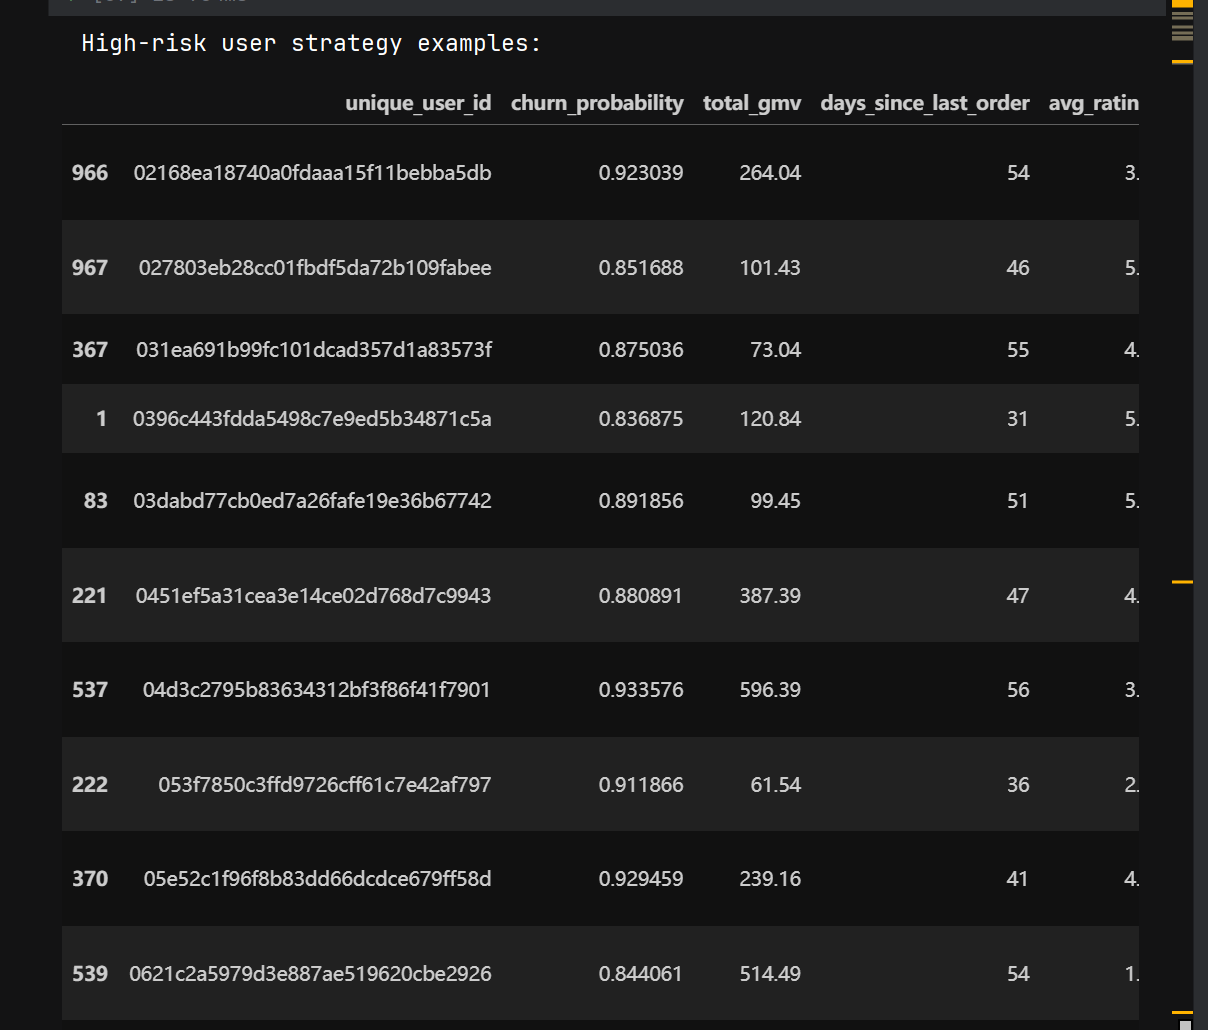
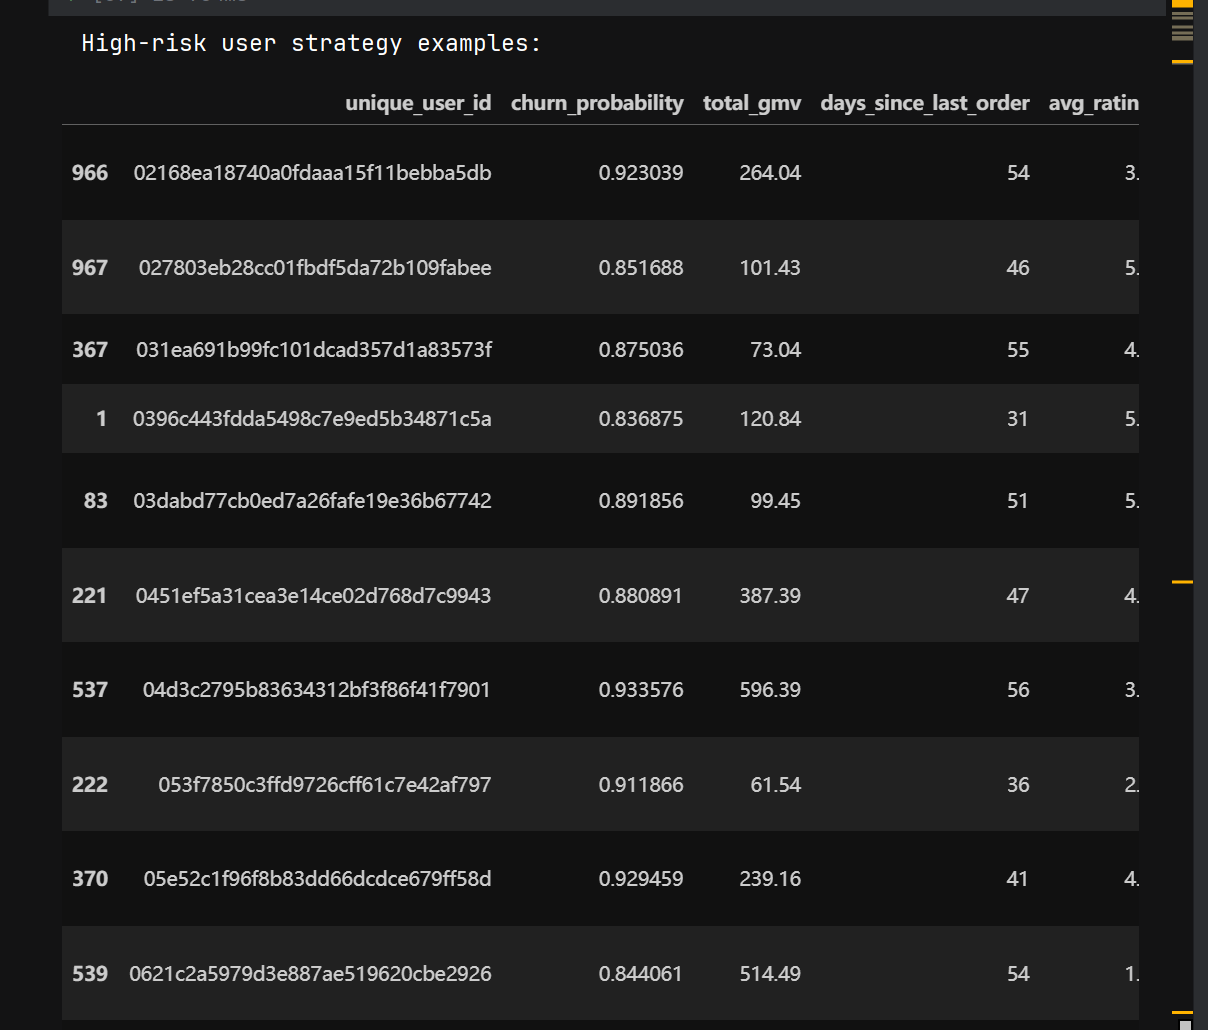

### 9.3 ROI Estimation

This section provides a simple business estimate of the potential return from retention actions. The goal is not to claim an exact financial forecast, but to translate the churn model into a clearer view of **cost, expected recovery, and possible value creation**.

Because the assumptions are simplified, the ROI output should be read as a decision-support scenario rather than a final business truth.

In [68]:
# 9.3 ROI Estimation

# Simple business assumptions
assumptions = {
    'avg_clv': 500,              # average retained value per recovered user
    'cost_low': 10,
    'cost_medium': 40,
    'cost_high': 120,
    'success_low': 0.05,
    'success_medium': 0.12,
    'success_high': 0.20
}

risk_counts = df_latest['risk_level'].value_counts()

roi_df = pd.DataFrame({
    'Risk Level': ['Low Risk', 'Medium Risk', 'High Risk'],
    'Users': [
        risk_counts.get('Low Risk', 0),
        risk_counts.get('Medium Risk', 0),
        risk_counts.get('High Risk', 0)
    ],
    'Cost per User': [
        assumptions['cost_low'],
        assumptions['cost_medium'],
        assumptions['cost_high']
    ],
    'Expected Success Rate': [
        assumptions['success_low'],
        assumptions['success_medium'],
        assumptions['success_high']
    ]
})

roi_df['Total Cost'] = roi_df['Users'] * roi_df['Cost per User']
roi_df['Expected Recovered Users'] = roi_df['Users'] * roi_df['Expected Success Rate']
roi_df['Expected Value'] = roi_df['Expected Recovered Users'] * assumptions['avg_clv']
roi_df['Net Value'] = roi_df['Expected Value'] - roi_df['Total Cost']
roi_df['ROI (%)'] = (roi_df['Net Value'] / roi_df['Total Cost'] * 100).round(2)

print("ROI estimation by risk segment:")
display(roi_df)

total_cost = roi_df['Total Cost'].sum()
total_value = roi_df['Expected Value'].sum()
total_net = roi_df['Net Value'].sum()
total_roi = (total_net / total_cost) * 100 if total_cost > 0 else 0

print(f"Total cost   : {total_cost:,.2f}")
print(f"Expected value: {total_value:,.2f}")
print(f"Net value    : {total_net:,.2f}")
print(f"Overall ROI  : {total_roi:.2f}%")

ROI estimation by risk segment:


,Risk Level,Users,Cost per User,Expected Success Rate,Total Cost,Expected Recovered Users,Expected Value,Net Value,ROI (%)
0,Low Risk,165,10,0.05,1650,8.25,4125.0,2475.0,150.00
1,Medium Risk,310,40,0.12,12400,37.20,18600.0,6200.0,50.00
2,High Risk,355,120,0.20,42600,71.00,35500.0,-7100.0,-16.67


Total cost   : 56,650.00
Expected value: 58,225.00
Net value    : 1,575.00
Overall ROI  : 2.78%


### ROI Estimation Analysis

The ROI estimate shows a **mixed business picture**. Under the current assumptions, **Low Risk** and **Medium Risk** interventions remain positive, while **High Risk** intervention becomes negative because the higher contact cost offsets the expected recovery value. Overall, the scenario still produces a small positive ROI of **2.78%**.

This is a useful but cautious result. It suggests that retention action can create value, but not all high-risk campaigns are automatically profitable. In practice, this means the best strategy may not be to target the highest-risk users most aggressively, but to balance **risk level, user value, and intervention cost** more carefully.

## 10. Key Findings Summary

### 1. Churn prediction performance
- The best-performing model was **Random Forest** from an overall comparison perspective.
- Tree-based models outperformed Logistic Regression on most headline metrics.
- However, all models still showed **limited global separation ability**, with AUC remaining relatively low.

### 2. Main churn drivers
- The most important signals were mainly related to **purchase activity**, **recency**, and **service experience**.
- Key features included:
  - ``total_category_purchases``
  - ``recency_ratio``
  - ``days_since_last_order``
  - ``avg_rating`` / ``rating_std``
  - ``avg_delivery_days``

### 3. Risk segmentation insight
- The model produced meaningful score variation and supported **Low / Medium / High Risk** grouping.
- Actual churn rate increased across risk segments, showing that the scores had practical ranking value.
- However, even the Low Risk group still had a relatively high churn rate, which means segmentation is useful for **priority setting**, not for identifying a truly safe group.

### 4. High-value risk concentration
- A relatively small group of **high-value high-risk users** accounted for a disproportionately large share of GMV.
- This suggests that retention should focus not only on churn probability, but also on **revenue exposure**.

### 5. Business implication
- The model is already useful for **risk prioritisation and campaign targeting**.
- At the same time, its limitations mean it should be treated as a **decision-support tool**, not as a perfect churn detector.

## 10.2 Business Recommendations

### Short-term actions
- Prioritise **high-value high-risk users** for immediate retention contact.
- Use stronger offers only for users with both **high churn risk** and **high revenue value**.
- For users with low ratings or delivery problems, combine incentives with **service recovery** rather than discounting alone.

### Medium-term actions
- Build a regular retention workflow based on **risk segmentation**.
- Use lighter-touch campaigns for Low Risk users and more targeted actions for Medium Risk users.
- Test different interventions separately for **inactivity-driven**, **service-driven**, and **value-driven** churn profiles.

### Long-term actions
- Improve the model by adding richer behavioural and marketing-response features.
- Revisit the churn definition and threshold logic to improve separation between churned and active users.
- Integrate churn scoring into a broader customer lifecycle system with **retention**, **value**, and **recommendation** signals combined.

## 10.3 Project Value Quantification

### Financial perspective
- The retention framework suggests that churn scoring can support **more selective spending** instead of broad untargeted campaigns.
- Under the current ROI assumptions, retention action remains **potentially positive overall**, but profitability differs across risk groups.
- This means the main financial value of the project lies in **better allocation of intervention cost**.

### Operational perspective
- The project creates a repeatable workflow for:
  - churn scoring
  - risk segmentation
  - high-priority user identification
  - strategy matching
- This can improve the speed and consistency of retention decision-making.

### Strategic perspective
- The model helps shift retention from intuition-based action to **data-supported prioritisation**.
- Even with current limitations, it provides a foundation for a broader customer lifecycle system that links **risk**, **value**, and **intervention strategy**.

## 10.4 Final Reflection

This project shows that churn prediction can already support **risk ranking**, **user prioritisation**, and **retention planning**. The strongest value of the current pipeline is not perfect classification, but the ability to turn customer data into a more structured retention workflow.

At the same time, the results also highlight important limitations. The dataset is highly churn-heavy, the active group is small, and several important predictors are close to the churn definition itself. This means the model is useful, but it should still be interpreted with caution.

Overall, the project provides a solid baseline for future improvement. The next stage should focus on **better target design**, **richer features**, and **more realistic intervention testing**, so that the system moves from useful prediction toward stronger business impact.

## 10.5 Save Final Outputs

This section saves the main outputs of the churn project, including model comparison, feature importance, scored users, high-value high-risk users, retention strategy, and ROI estimation. This makes the project easier to review, reuse, and present later.

In [69]:
# 10.5 Save Final Outputs

from pathlib import Path

output_dir = Path("output/06_churn_prediction")
output_dir.mkdir(parents=True, exist_ok=True)

# 1. Model comparison
model_comparison.to_csv(output_dir / "model_comparison.csv", index=False)

# 2. Full feature importance
feature_importance.to_csv(output_dir / "feature_importance_full.csv", index=False)

# 3. Scored snapshot-level table
df_scored.to_csv(output_dir / "user_churn_scores_snapshot_level.csv", index=False)

# 4. Latest user-level scored table
df_latest.to_csv(output_dir / "user_churn_scores_latest_user_level.csv", index=False)

# 5. High-value high-risk users
hvhr_users.to_csv(output_dir / "high_value_high_risk_users.csv", index=False)

# 6. Top 20 high-value high-risk users
top_20_hvhr.to_csv(output_dir / "top20_high_value_high_risk_users.csv", index=False)

# 7. Retention strategy framework
retention_strategy.to_csv(output_dir / "retention_strategy_framework.csv", index=False)

# 8. ROI estimation
roi_df.to_csv(output_dir / "roi_estimation.csv", index=False)

# 9. Example personalised strategies for latest users
df_latest[[
    'unique_user_id',
    'snapshot_id',
    'churn_probability',
    'risk_level',
    'total_gmv',
    'days_since_last_order',
    'avg_rating',
    'avg_delivery_days',
    'personalized_strategy'
]].to_csv(output_dir / "user_personalized_strategies.csv", index=False)

print(f"All outputs saved to: {output_dir.resolve()}")
print("\nSaved files:")
for file in sorted(output_dir.glob("*")):
    print("-", file.name)

All outputs saved to: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\Statistical_analysis_report\output\06_churn_prediction

Saved files:
- feature_importance_full.csv
- high_value_high_risk_users.csv
- model_comparison.csv
- retention_strategy_framework.csv
- roi_estimation.csv
- top20_high_value_high_risk_users.csv
- user_churn_scores_latest_user_level.csv
- user_churn_scores_snapshot_level.csv
- user_personalized_strategies.csv
